In [162]:
import os

# Set your W&B token
os.environ["WANDB_API_KEY"]="???"

import torch
import torchvision
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import torchvision.transforms as T
import numpy as np
import cv2
import graphviz
import pytorch_lightning as pl
import torchmetrics
import wandb
import timm
import albumentations as A
import pandas as pd
import ttach as tta
import lightning
from tqdm import tqdm
from time import time
from pprint import pprint
from scipy.stats import rankdata
from hyperopt import fmin, tpe, hp, Trials, STATUS_OK

from typing import Dict, Any, Optional, Callable, Union
from albumentations.pytorch import ToTensorV2
from torchview import draw_graph
from scipy.ndimage import gaussian_laplace
from pytorch_lightning.loggers import WandbLogger
from pytorch_lightning.callbacks import ModelCheckpoint, LearningRateMonitor
from PIL import Image
from iterstrat.ml_stratifiers import MultilabelStratifiedKFold
from sklearn.metrics import (
    roc_auc_score, f1_score, precision_score, recall_score,
    confusion_matrix
)
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsRestClassifier
from lightning.pytorch import loggers as pl_loggers
from lightning.pytorch.callbacks import LearningRateMonitor, ModelCheckpoint

%matplotlib inline

In [2]:
DEVICE = "cuda"

# Agenda

1. [Model Distillation](#Model_Distillation)
2. [Kaggle Black Magic](#Kaggle_Black_Magic)

<a id='Model_Distillation'></a>
# Model Distillation

## Utils

In [3]:
class LitTrainer(lightning.LightningModule):
    def __init__(
        self,
        model,
        forward,
        optimizer,
        scheduler,
        scheduler_params,
        batch_key,
        metric_input_key,
        metric_output_key,
        val_metrics,
        train_metrics=None,
    ):
        super().__init__()

        self.model = model
        self._forward = forward
        self._optimizer = optimizer
        self._scheduler = scheduler
        self._scheduler_params = scheduler_params
        self._batch_key = batch_key

        self._metric_input_key = metric_input_key
        self._metric_output_key = metric_output_key
        self._val_metrics = val_metrics
        self._train_metrics = train_metrics

    def _aggregate_outputs(self, losses, inputs, outputs):
        united = losses
        united.update({"input_" + k: v for k, v in inputs.items()})
        united.update({"output_" + k: v for k, v in outputs.items()})
        return united

    def training_step(self, batch):

        start_time = time()
        losses, inputs, outputs = self._forward(self, batch, epoch=self.current_epoch)
        model_time = time() - start_time

        if self._train_metrics is not None:
            self._train_metrics.update(
                outputs[self._metric_output_key],
                inputs[self._metric_input_key]
            )

        for k, v in losses.items():
            self.log(
                "train_" + k,
                v,
                on_step=True,
                on_epoch=False,
                prog_bar=True,
                logger=True,
                batch_size=inputs[self._batch_key].shape[0],
                sync_dist=True,
            )
            self.log(
                "train_avg_" + k,
                v,
                on_step=False,
                on_epoch=True,
                prog_bar=True,
                logger=True,
                batch_size=inputs[self._batch_key].shape[0],
                sync_dist=True,
            )
        self.log(
            "train_model_time",
            model_time,
            on_step=True,
            on_epoch=False,
            prog_bar=True,
            logger=True,
            batch_size=1,
            sync_dist=True,
        )
        self.log(
            "train_avg_model_time",
            model_time,
            on_step=False,
            on_epoch=True,
            prog_bar=True,
            logger=True,
            batch_size=1,
            sync_dist=True,
        )

        return self._aggregate_outputs(losses, inputs, outputs)

    def validation_step(self, batch, batch_idx):

        start_time = time()
        losses, inputs, outputs = self._forward(self, batch, epoch=self.current_epoch)
        model_time = time() - start_time

        if self._val_metrics is not None:
            self._val_metrics.update(
                outputs[self._metric_output_key],
                inputs[self._metric_input_key]
            )

        for k, v in losses.items():
            self.log(
                "valid_" + k,
                v,
                on_step=True,
                on_epoch=False,
                prog_bar=True,
                logger=True,
                batch_size=inputs[self._batch_key].shape[0],
                sync_dist=True,
            )
            self.log(
                "valid_avg_" + k,
                v,
                on_step=False,
                on_epoch=True,
                prog_bar=True,
                logger=True,
                batch_size=inputs[self._batch_key].shape[0],
                sync_dist=True,
            )
        self.log(
            "valid_model_time",
            model_time,
            on_step=True,
            on_epoch=False,
            prog_bar=True,
            logger=True,
            batch_size=1,
            sync_dist=True,
        )
        self.log(
            "valid_avg_model_time",
            model_time,
            on_step=False,
            on_epoch=True,
            prog_bar=True,
            logger=True,
            batch_size=1,
            sync_dist=True,
        )

        return self._aggregate_outputs(losses, inputs, outputs)

    def on_train_epoch_end(self):
        metric_values = self._train_metrics.compute()
        self.log_dict(
            {"train_"+k:v for k,v in metric_values.items()},
            on_step=False,
            on_epoch=True,
            prog_bar=False,
            sync_dist=True,
        )
        self._train_metrics.reset()

    def on_validation_epoch_end(self):
        metric_values = self._val_metrics.compute()
        self.log_dict(
            {"valid_"+k:v for k,v in metric_values.items()},
            on_step=False,
            on_epoch=True,
            prog_bar=False,
            sync_dist=True,
        )
        self._val_metrics.reset()

    def configure_optimizers(self):
        scheduler = {"scheduler": self._scheduler}
        scheduler.update(self._scheduler_params)
        return (
            [self._optimizer],
            [scheduler],
        )

def lightning_training(
    train_df: Optional[pd.DataFrame],
    val_df: Optional[pd.DataFrame],
    exp_name: str,
    fold_id: Optional[int],
    forward_batch_key: str,
    train_dataset_class: torch.utils.data.Dataset,
    val_dataset_class: Optional[torch.utils.data.Dataset],
    train_dataset_config: dict,
    val_dataset_config: Optional[dict],
    train_dataloader_config: dict,
    val_dataloader_config: Optional[dict],
    nn_model_class: torch.nn.Module,
    nn_model_config: dict,
    optimizer_init: Callable,
    scheduler_init: Callable,
    scheduler_params: dict,
    forward: Union[torch.nn.Module, Callable],
    n_epochs: int,
    main_metric: str,
    metric_mode: str,
    metric_input_key: str,
    metric_output_key: str,
    val_metrics: torchmetrics.MetricCollection,
    train_metrics: Optional[torchmetrics.MetricCollection] = None,
    # It is not really Callable. It just lambda that will init List of callbacks
    # each time. It is just done for safe CV training.
    callbacks: Optional[Callable] = None,
    checkpoint_callback_params: dict = {},
    wandb_logger_params: dict = {},
    trainer_params: dict = {},
    precision_mode: str = "32-true",
    n_checkpoints_to_save: int = 3,
    log_every_n_steps: int = 3,
    train_strategy: str = "auto",

    use_sampler: bool = False,
    sampler_with_replacement: bool = True,
    class_weights_strategy: Optional[str] = "balanced",
    power_value: float = -0.5,
):
    # Set device
    if torch.cuda.is_available():
        device = "cuda"
    else:
        device = "cpu"
    print(f"Training Device : {device}")

    train_dataset = train_dataset_class(
        df=train_df,
        **train_dataset_config,
    )
    val_dataset = val_dataset_class(
        df=val_df,
        **val_dataset_config,
    )

    if use_sampler:
        if class_weights_strategy == "sqrt":
            labels = pd.Series(train_dataset.balance_series)
            class_weights = (labels.value_counts() / labels.value_counts().sum()) ** power_value
            class_weights = class_weights.to_dict()
        elif class_weights_strategy == "balanced":
            labels = pd.Series(train_dataset.balance_series)
            class_weights = 1.0 / labels.value_counts()
            class_weights = class_weights.to_dict()
        else:
            raise RuntimeError(f"Unsuported class_weights_strategy: {class_weights_strategy}")
        print("Using next class weights:")
        pprint(class_weights)
        sample_weights = np.array([class_weights[el] for el in train_dataset.balance_series])
        assert len(sample_weights) == len(train_dataset)
        sampler = torch.utils.data.WeightedRandomSampler(
            sample_weights, len(sample_weights), replacement=sampler_with_replacement
        )
        print("Sampler Created")
    else:
        sampler = None

    loaders = {
        "train": torch.utils.data.DataLoader(
            train_dataset,
            sampler=sampler,
            **train_dataloader_config,
        ),
        "valid": torch.utils.data.DataLoader(
            val_dataset, 
            **val_dataloader_config
        )
    }

    model = nn_model_class(**nn_model_config).to(device)

    for k in loaders.keys():
        print(f"{k} Loader Len = {len(loaders[k])}")

    optimizer = optimizer_init(model)
    scheduler = scheduler_init(optimizer, len(loaders["train"]))

    if not isinstance(forward, torch.nn.Module):
        forward = forward()

    lightning_model = LitTrainer(
        model,
        forward=forward,
        optimizer=optimizer,
        scheduler=scheduler,
        scheduler_params=scheduler_params,
        batch_key=forward_batch_key,
        metric_input_key=metric_input_key,
        metric_output_key=metric_output_key,
        val_metrics=val_metrics,
        train_metrics=train_metrics
    )

    all_callbacks = [
        ModelCheckpoint(
            dirpath=os.path.join(exp_name, "checkpoints"),
            save_top_k=n_checkpoints_to_save,
            mode=metric_mode,
            monitor=main_metric,
            **checkpoint_callback_params,
        ),
        LearningRateMonitor(logging_interval="step"),
    ]
    if callbacks is not None:
        all_callbacks += callbacks()

    wandb_logger = pl_loggers.WandbLogger(
        save_dir=exp_name,
        name="/".join(exp_name.split("/")[1:]) if "/" in exp_name else exp_name,
        **wandb_logger_params,
    )
    trainer = lightning.Trainer(
        devices=-1,
        precision=precision_mode,
        strategy=train_strategy,
        max_epochs=n_epochs,
        logger=wandb_logger,
        log_every_n_steps=log_every_n_steps,
        callbacks=all_callbacks,
        **trainer_params,
    )
    trainer.fit(model=lightning_model, train_dataloaders=loaders["train"], val_dataloaders=loaders["valid"])
    wandb.finish()
    return all_callbacks[0].best_model_path

In [4]:
CLASSES = ["Cat", "Dog", "Moris", "Motya", "Biatrix"]
N_CLASSES = len(CLASSES)

class MultilabelImageDataset(torch.utils.data.Dataset):
    def __init__(self, df, img_dir, ext=".jpg", balance_column=None, transform=None):
        self.df = df
        self.img_dir = img_dir
        self.transform = transform
        self.ext = ext
        if balance_column is not None:
            self.balance_series = self.df[balance_column]
        else:
            self.balance_series = None

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = os.path.join(self.img_dir, row["image_id"] + self.ext)
        image = np.array(Image.open(img_path).convert("RGB"))
        labels = torch.tensor(row[CLASSES].values.astype(np.float32))

        if self.transform:
            image = self.transform(image=image)["image"]

        return image, labels

In [5]:
def count_parameters(model: nn.Module) -> dict:
    """
    Count total and trainable parameters of a PyTorch model.

    Parameters
    ----------
    model : nn.Module
        The PyTorch model to inspect.

    Returns
    -------
    dict
        A dictionary with:
        - "total": total number of parameters
        - "trainable": number of trainable parameters
        - "non_trainable": number of frozen parameters
    """
    total = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return {
        "total": total,
        "trainable": trainable,
        "non_trainable": total - trainable,
    }


## Prepare data

In [129]:
def create_folds(input_df, n_splits=5):
    mskf = MultilabelStratifiedKFold(n_splits=n_splits, shuffle=True, random_state=95431)
    input_df["fold"] = -1
    for fold, (_, val_idx) in enumerate(mskf.split(input_df, input_df[CLASSES].values)):
        input_df.loc[val_idx, "fold"] = fold
    return input_df

In [8]:
full_df = pd.read_csv(
    "../../data/cats-and-dogs-plus-plus/train.csv"
)
full_df = create_folds(full_df)
full_df.head()

,image_id,Cat,Dog,Moris,Motya,Biatrix,fold
0,7e17a6e589f9c891857b32bbb3652d19b7d5a215,0,0,0,0,0,2
1,7ad97bd6c7ef98373f43f2bbd1e41b2bbff4687e,1,0,0,0,0,3
2,d29be872d012d8766c5942847d1d721788fd9511,0,1,0,0,0,2
3,bec7727bfc721629997d782ec020ee555990128f,0,1,0,0,0,0
4,58bb7362153d945f48721004bc8fb2ee73a855b0,0,1,0,0,0,0


In [10]:
for cls_name in ["Moris", "Motya", "Biatrix"]:
    print(full_df[cls_name].value_counts(normalize=True))

Moris
0    0.995432
1    0.004568
Name: proportion, dtype: float64
Motya
0    0.996574
1    0.003426
Name: proportion, dtype: float64
Biatrix
0    0.996656
1    0.003344
Name: proportion, dtype: float64


In [11]:
def create_balance_column(row):
    for cls_n in ["Biatrix", "Motya", "Moris"]:
        if row[cls_n]:
            return cls_n
    if row["Cat"] and row["Dog"]:
        return "Cat_Dog"
    elif row["Cat"]:
        return "Cat"
    elif row["Dog"]:
        return "Dog"
    else:
        return "No Animals"

full_df["balance_column"] = full_df.apply(create_balance_column, axis=1)
full_df["balance_column"].value_counts()

balance_column
Cat           4989
Dog           4984
No Animals    2162
Motya           42
Moris           42
Biatrix         41
Name: count, dtype: int64

## Classical Supervised Training

In [12]:
class BCEForward(nn.Module):
    def __init__(
        self,
        loss_function,
        output_key="logits",
        input_key="targets",
    ):
        super().__init__()
        self.loss_function = loss_function
        self.output_key = output_key
        self.input_key = input_key

    def forward(self, runner, batch, epoch=None):

        image, labels = batch

        output = dict()
        output["logits"] = runner.model(image)
        output["predictions"] = (torch.sigmoid(output["logits"]) > 0.5).float()

        inputs = {
            "targets": labels.float(),
        }

        losses = {
            "loss": self.loss_function(
                output[self.output_key],
                inputs[self.input_key],
            )
        }

        return losses, inputs, output

In [ ]:
efnetv2b3_model_path = lightning_training(
    train_df=full_df[full_df["fold"] != 0],
    val_df=full_df[full_df["fold"] == 0],
    exp_name="logdirs/efnetv2b3",
    fold_id=0,
    forward_batch_key="targets",
    train_dataset_class=MultilabelImageDataset,
    val_dataset_class=MultilabelImageDataset,
    train_dataset_config=dict(
        img_dir="../../data/cats-and-dogs-plus-plus/train",
        transform=A.Compose([
            A.Resize(224, 224),
            A.VerticalFlip(p=0.5),
            A.HorizontalFlip(p=0.5),
            A.RandomRotate90(p=0.3),
            A.ShiftScaleRotate(
              shift_limit=0.1,
              scale_limit=0.15,
              rotate_limit=15,
              p=0.5
            ),
            A.RandomBrightnessContrast(
              brightness_limit=0.2,
              contrast_limit=0.2,
              p=0.5
            ),
            A.HueSaturationValue(
              hue_shift_limit=10,
              sat_shift_limit=20,
              val_shift_limit=15,
              p=0.3
            ),
            A.GaussNoise(var_limit=(10.0, 30.0), p=0.2),
            A.Blur(blur_limit=3, p=0.2),
            A.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
            ToTensorV2()
          ]),
        balance_column="balance_column"
    ),
    val_dataset_config=dict(
        img_dir="../../data/cats-and-dogs-plus-plus/train",
        transform=A.Compose([
            A.Resize(224, 224),
            A.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
            ToTensorV2()
        ])
    ),
    use_sampler=True,
    train_dataloader_config={
        "batch_size": 64,
        "shuffle": False,
        "drop_last": True,
        "num_workers": 8,
        "pin_memory": True,
    },
    val_dataloader_config={
        "batch_size": 64,
        "shuffle": False,
        "drop_last": False,
        "num_workers": 8,
        "pin_memory": True,
    },
    nn_model_class=timm.create_model,
    nn_model_config={
        "model_name": "tf_efficientnetv2_b3.in1k",
        "num_classes": len(CLASSES),
        "pretrained": True
    },
    optimizer_init=lambda model: torch.optim.Adam(model.parameters(), lr=1e-3),
    scheduler_init=lambda optimizer, len_train: torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer, 
        eta_min=1e-6,
        T_max=len_train * 5,
    ),
    scheduler_params={"interval": "step"},
    forward=lambda: BCEForward(
        torch.nn.BCEWithLogitsLoss(),
        input_key="targets",
        output_key="logits",
    ),
    n_epochs=10,
    main_metric="valid_MultilabelF1Score",
    metric_mode="max",
    metric_input_key="targets",
    metric_output_key="predictions",
    val_metrics=torchmetrics.MetricCollection(
        metrics=[
            torchmetrics.Accuracy(average="macro", task="multilabel", num_classes=len(CLASSES), num_labels=len(CLASSES),),
            torchmetrics.Recall(average="macro", task="multilabel", num_classes=len(CLASSES), num_labels=len(CLASSES),),
            torchmetrics.Precision(average="macro", task="multilabel", num_classes=len(CLASSES), num_labels=len(CLASSES),),
            torchmetrics.F1Score(average="macro", task="multilabel", num_classes=len(CLASSES), num_labels=len(CLASSES),),
        ],
        compute_groups=False
    ),
    train_metrics=torchmetrics.MetricCollection(
        metrics=[
            torchmetrics.Accuracy(average="macro", task="multilabel", num_classes=len(CLASSES), num_labels=len(CLASSES),),
            torchmetrics.Recall(average="macro", task="multilabel", num_classes=len(CLASSES), num_labels=len(CLASSES),),
            torchmetrics.Precision(average="macro", task="multilabel", num_classes=len(CLASSES), num_labels=len(CLASSES),),
            torchmetrics.F1Score(average="macro", task="multilabel", num_classes=len(CLASSES), num_labels=len(CLASSES),),
        ],
        compute_groups=False
    ),
    checkpoint_callback_params=dict(
        save_last=True,
        auto_insert_metric_name=True,
        save_weights_only=True,
        save_on_train_epoch_end=True,
        filename="{epoch}-{step}-{valid_MultilabelF1Score:.3f}",
    ),
    precision_mode="16-mixed",
    wandb_logger_params={
        "project": "kse_deep_learning_course",
    }
)

In [ ]:
mobnet_model_path = lightning_training(
    train_df=full_df[full_df["fold"] != 0],
    val_df=full_df[full_df["fold"] == 0],
    exp_name="logdirs/mobnet",
    fold_id=0,
    forward_batch_key="targets",
    train_dataset_class=MultilabelImageDataset,
    val_dataset_class=MultilabelImageDataset,
    train_dataset_config=dict(
        img_dir="../../data/cats-and-dogs-plus-plus/train",
        transform=A.Compose([
            A.Resize(224, 224),
            A.VerticalFlip(p=0.5),
            A.HorizontalFlip(p=0.5),
            A.RandomRotate90(p=0.3),
            A.ShiftScaleRotate(
              shift_limit=0.1,
              scale_limit=0.15,
              rotate_limit=15,
              p=0.5
            ),
            A.RandomBrightnessContrast(
              brightness_limit=0.2,
              contrast_limit=0.2,
              p=0.5
            ),
            A.HueSaturationValue(
              hue_shift_limit=10,
              sat_shift_limit=20,
              val_shift_limit=15,
              p=0.3
            ),
            A.GaussNoise(var_limit=(10.0, 30.0), p=0.2),
            A.Blur(blur_limit=3, p=0.2),
            A.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
            ToTensorV2()
          ]),
        balance_column="balance_column"
    ),
    val_dataset_config=dict(
        img_dir="../../data/cats-and-dogs-plus-plus/train",
        transform=A.Compose([
            A.Resize(224, 224),
            A.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
            ToTensorV2()
        ])
    ),
    use_sampler=True,
    train_dataloader_config={
        "batch_size": 64,
        "shuffle": False,
        "drop_last": True,
        "num_workers": 8,
        "pin_memory": True,
    },
    val_dataloader_config={
        "batch_size": 64,
        "shuffle": False,
        "drop_last": False,
        "num_workers": 8,
        "pin_memory": True,
    },
    nn_model_class=timm.create_model,
    nn_model_config={
        "model_name": "mobilenetv3_small_050.lamb_in1k",
        "num_classes": len(CLASSES),
        "pretrained": True
    },
    optimizer_init=lambda model: torch.optim.Adam(model.parameters(), lr=1e-3),
    scheduler_init=lambda optimizer, len_train: torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer, 
        eta_min=1e-6,
        T_max=len_train * 5,
    ),
    scheduler_params={"interval": "step"},
    forward=lambda: BCEForward(
        torch.nn.BCEWithLogitsLoss(),
        input_key="targets",
        output_key="logits",
    ),
    n_epochs=10,
    main_metric="valid_MultilabelF1Score",
    metric_mode="max",
    metric_input_key="targets",
    metric_output_key="predictions",
    val_metrics=torchmetrics.MetricCollection(
        metrics=[
            torchmetrics.Accuracy(average="macro", task="multilabel", num_classes=len(CLASSES), num_labels=len(CLASSES),),
            torchmetrics.Recall(average="macro", task="multilabel", num_classes=len(CLASSES), num_labels=len(CLASSES),),
            torchmetrics.Precision(average="macro", task="multilabel", num_classes=len(CLASSES), num_labels=len(CLASSES),),
            torchmetrics.F1Score(average="macro", task="multilabel", num_classes=len(CLASSES), num_labels=len(CLASSES),),
        ],
        compute_groups=False
    ),
    train_metrics=torchmetrics.MetricCollection(
        metrics=[
            torchmetrics.Accuracy(average="macro", task="multilabel", num_classes=len(CLASSES), num_labels=len(CLASSES),),
            torchmetrics.Recall(average="macro", task="multilabel", num_classes=len(CLASSES), num_labels=len(CLASSES),),
            torchmetrics.Precision(average="macro", task="multilabel", num_classes=len(CLASSES), num_labels=len(CLASSES),),
            torchmetrics.F1Score(average="macro", task="multilabel", num_classes=len(CLASSES), num_labels=len(CLASSES),),
        ],
        compute_groups=False
    ),
    checkpoint_callback_params=dict(
        save_last=True,
        auto_insert_metric_name=True,
        save_weights_only=True,
        save_on_train_epoch_end=True,
        filename="{epoch}-{step}-{valid_MultilabelF1Score:.3f}",
    ),
    precision_mode="16-mixed",
    wandb_logger_params={
        "project": "kse_deep_learning_course",
    }
)

In [13]:
print("tf_efficientnetv2_b3.in1k parameters", count_parameters(timm.create_model("tf_efficientnetv2_b3.in1k")))
print("mobilenetv3_small_050.lamb_in1k parameters", count_parameters(timm.create_model("mobilenetv3_small_050.lamb_in1k")))

tf_efficientnetv2_b3.in1k parameters {'total': 14358406, 'trainable': 14358406, 'non_trainable': 0}
mobilenetv3_small_050.lamb_in1k parameters {'total': 1593224, 'trainable': 1593224, 'non_trainable': 0}


BCE training Model results:

<img src="images/bce_plots_metrics.png">

## Distillation

## 🎯 Goal
Model Distillation transfers knowledge from a large, accurate model (teacher) into a smaller, faster model (student). The student learns to mimic the behavior of the teacher, usually by learning from its soft probability outputs rather than only from hard labels. This allows powerful models to be compressed into lightweight versions suitable for real-time or resource-limited environments.

---

## Why Do We Need Distillation?

| Challenge | How Distillation Helps |
|----------|-------------------------|
| Large models too slow for deployment | Student is compact and fast |
| Ensembles expensive at inference | Knowledge distilled into a single model |
| Abundant unlabeled data | Teacher can generate soft pseudo-labels |
| Hard labels are too coarse | Soft probabilities carry richer information |
| Need cross-architecture transfer | Works for CNN → Transformer, Transformer → CNN, etc. |

Teacher soft predictions reveal:
- class similarity patterns  
- relative confidences  
- structure in the output space  

---

## 🔧 How Distillation Works ([Distilling the Knowledge in a Neural Network](https://arxiv.org/pdf/1503.02531))

The student is trained to match the teacher’s temperature-scaled softmax distribution.

Teacher:
$$
p_i^{(T)} = \text{softmax}\left(\frac{z_i}{T}\right)
$$

Student:
$$
q_i^{(T)} = \text{softmax}\left(\frac{s_i}{T}\right)
$$

Distillation loss (KL divergence):
$$
\mathcal{L}_{KD} = T^2 \cdot \mathrm{KL}\left(p^{(T)} \,\|\, q^{(T)}\right)
$$

Often combined with cross-entropy on true labels:
$$
\mathcal{L} = (1 - \alpha)\mathcal{L}_{KD} + \alpha\mathcal{L}_{CE}
$$

---

## Use-Case Examples

### Vision
- Compressing ResNet/ViT for mobile deployment  
- Distilling detection/segmentation models for real-time inference  
- Replacing ensembles in Kaggle competitions  

### Audio
- Distilling audio transformers into lightweight CNNs  
- Real-time UAV detection, eco-acoustics, bird-call classification  

### NLP / LLMs
- Small LLMs distilled from large language models  
- Reduces memory and improves latency  

### Medical Imaging
- Deploy compact diagnostic models on hospital hardware  
- Use ensembles as teachers for student training  

---

## 🧨 Possible Downsides

| Downside | Explanation |
|----------|-------------|
| Inherits teacher mistakes | Student learns all teacher biases |
| Requires strong teacher | Weak teacher → weak student |
| Sensitive to hyperparameters | Temperature and α must be tuned |
| Limited student capacity | Too-small model cannot mimic teacher |
| Overfitting to teacher | Only soft labels can amplify noise |
| No guaranteed improvement | Sometimes standard training is better |



## Distilation training

In [ ]:
initialized_teacher_model = timm.create_model("tf_efficientnetv2_b3.in1k", num_classes=len(CLASSES))
initialized_teacher_model.load_state_dict(
    {k.replace("model.", ""): v for k, v in torch.load(efnetv2b3_model_path, map_location="cpu")["state_dict"].items()}
)
initialized_teacher_model.eval();
# tta_transforms = tta.aliases.flip_transform()  # H/V flips
# tta_initialized_teacher_model = tta.ClassificationTTAWrapper(initialized_teacher_model, tta_transforms)

In [ ]:
class HintonDistillationForward(nn.Module):
    def __init__(
        self,
        teacher_model,
        output_key="logits",
        input_key="targets",

        temperature: float = 2.0,
        alpha: float = 0.5,
    ):
        super().__init__()
        self.teacher_model = teacher_model
        self.output_key = output_key
        self.input_key = input_key

        self.temperature = temperature
        self.alpha = alpha

    def forward(self, runner, batch, epoch=None):

        image, labels = batch

        with torch.no_grad():
            teacher_logits = self.teacher_model(image).detach()

        student_logits = runner.model(image)

        labels = labels.float()

        # Temperature-scaled teacher probabilities for multilabel: sigmoid(z / T)
        teacher_probs = torch.sigmoid(teacher_logits / self.temperature)

        # ---- Student outputs at temperature T ----
        student_logits_T = student_logits / self.temperature
    
        # BCE with logits expects logits + target probs in [0, 1]
        soft_loss = F.binary_cross_entropy_with_logits(
            student_logits_T, teacher_probs, reduction="mean"
        )
    
        # Scale by T^2 (as in the paper) to keep gradient scales comparable
        soft_loss = soft_loss * (self.temperature ** 2)
    
        # ---- Hard-label loss at T = 1 ----
        hard_loss = F.binary_cross_entropy_with_logits(
            student_logits, labels, reduction="mean"
        )
    
        # Combine soft and hard losses
        loss = (1.0 - self.alpha) * soft_loss + self.alpha * hard_loss

        output = dict()
        output["logits"] = student_logits
        output["predictions"] = (torch.sigmoid(student_logits) > 0.5).float()

        inputs = {
            "targets": labels,
        }

        losses = {
            "loss": loss,
            "soft_loss": soft_loss,
            "hard_loss": hard_loss
        }

        return losses, inputs, output

In [ ]:
mobnet_hinton_distilled_model_path = lightning_training(
    train_df=full_df[full_df["fold"] != 0],
    val_df=full_df[full_df["fold"] == 0],
    exp_name="logdirs/mobnet_hinton_distilation",
    fold_id=0,
    forward_batch_key="targets",
    train_dataset_class=MultilabelImageDataset,
    val_dataset_class=MultilabelImageDataset,
    train_dataset_config=dict(
        img_dir="../../data/cats-and-dogs-plus-plus/train",
        transform=A.Compose([
            A.Resize(224, 224),
            A.VerticalFlip(p=0.5),
            A.HorizontalFlip(p=0.5),
            A.RandomRotate90(p=0.3),
            A.ShiftScaleRotate(
              shift_limit=0.1,
              scale_limit=0.15,
              rotate_limit=15,
              p=0.5
            ),
            A.RandomBrightnessContrast(
              brightness_limit=0.2,
              contrast_limit=0.2,
              p=0.5
            ),
            A.HueSaturationValue(
              hue_shift_limit=10,
              sat_shift_limit=20,
              val_shift_limit=15,
              p=0.3
            ),
            A.GaussNoise(var_limit=(10.0, 30.0), p=0.2),
            A.Blur(blur_limit=3, p=0.2),
            A.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
            ToTensorV2()
          ]),
        balance_column="balance_column"
    ),
    val_dataset_config=dict(
        img_dir="../../data/cats-and-dogs-plus-plus/train",
        transform=A.Compose([
            A.Resize(224, 224),
            A.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
            ToTensorV2()
        ])
    ),
    use_sampler=True,
    train_dataloader_config={
        "batch_size": 64,
        "shuffle": False,
        "drop_last": True,
        "num_workers": 8,
        "pin_memory": True,
    },
    val_dataloader_config={
        "batch_size": 64,
        "shuffle": False,
        "drop_last": False,
        "num_workers": 8,
        "pin_memory": True,
    },
    nn_model_class=timm.create_model,
    nn_model_config={
        "model_name": "mobilenetv3_small_050.lamb_in1k",
        "num_classes": len(CLASSES),
        "pretrained": True
    },
    optimizer_init=lambda model: torch.optim.Adam(model.parameters(), lr=1e-3),
    scheduler_init=lambda optimizer, len_train: torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer, 
        eta_min=1e-6,
        T_max=len_train * 5,
    ),
    scheduler_params={"interval": "step"},
    forward=lambda: HintonDistillationForward(
        teacher_model=initialized_teacher_model,
        input_key="targets",
        output_key="logits",
    ),
    n_epochs=10,
    main_metric="valid_MultilabelF1Score",
    metric_mode="max",
    metric_input_key="targets",
    metric_output_key="predictions",
    val_metrics=torchmetrics.MetricCollection(
        metrics=[
            torchmetrics.Accuracy(average="macro", task="multilabel", num_classes=len(CLASSES), num_labels=len(CLASSES),),
            torchmetrics.Recall(average="macro", task="multilabel", num_classes=len(CLASSES), num_labels=len(CLASSES),),
            torchmetrics.Precision(average="macro", task="multilabel", num_classes=len(CLASSES), num_labels=len(CLASSES),),
            torchmetrics.F1Score(average="macro", task="multilabel", num_classes=len(CLASSES), num_labels=len(CLASSES),),
        ],
        compute_groups=False
    ),
    train_metrics=torchmetrics.MetricCollection(
        metrics=[
            torchmetrics.Accuracy(average="macro", task="multilabel", num_classes=len(CLASSES), num_labels=len(CLASSES),),
            torchmetrics.Recall(average="macro", task="multilabel", num_classes=len(CLASSES), num_labels=len(CLASSES),),
            torchmetrics.Precision(average="macro", task="multilabel", num_classes=len(CLASSES), num_labels=len(CLASSES),),
            torchmetrics.F1Score(average="macro", task="multilabel", num_classes=len(CLASSES), num_labels=len(CLASSES),),
        ],
        compute_groups=False
    ),
    checkpoint_callback_params=dict(
        save_last=True,
        auto_insert_metric_name=True,
        save_weights_only=True,
        save_on_train_epoch_end=True,
        filename="{epoch}-{step}-{valid_MultilabelF1Score:.3f}",
    ),
    precision_mode="16-mixed",
    wandb_logger_params={
        "project": "kse_deep_learning_course",
    }
)

BCE training Model compared with Distillation results:

<img src="images/bce_and_distil_plots_metrics.png">

## Other Distillation Approaches ([FITNETS: HINTS FOR THIN DEEP NETS](https://arxiv.org/pdf/1412.6550))

While the original formulation of distillation focuses on matching the teacher’s softened output distributions, later research demonstrated that a significant portion of a model’s knowledge is contained inside its intermediate representations. This led to a wide family of *representation-based* distillation methods.

One influential direction is **feature matching**, where the student is encouraged to reproduce the hidden activations of the teacher. Instead of matching only the final logits, the student minimizes an L2, Smooth L1, or **cosine similarity** loss between corresponding intermediate feature maps. This encourages the student to encode similar spatial patterns, textures, and semantic structures, especially useful when the teacher and student differ in capacity or depth.

Another extension is **hint-based distillation** (FitNets), where shallow student layers are supervised using deeper teacher layers called “hints.” This helps the student learn higher-level abstractions early in training, making optimization easier and improving stability for very small student models.

**Attention-based distillation** further refines this idea by transferring not the raw features, but the *attention maps* (i.e., the spatial importance distributions) produced by the teacher. The student learns to focus on the same regions, preserving the teacher’s reasoning patterns even when feature dimensions differ. Methods such as Attention Transfer interpret teacher activations as spatial heatmaps and enforce similarity through normalized L2 or KL losses.

Beyond matching single-layer features, **relational knowledge distillation (RKD)** captures the geometry of the teacher’s representation space by matching *distances and angles* between pairs or triplets of samples. Instead of aligning absolute features, RKD preserves the *relations* among examples — a form of structural guidance that often generalizes better.

More recent approaches, such as **contrastive representation distillation (CRD)**, use contrastive learning: the student is trained to bring its representations closer to the teacher’s for the same sample while pushing apart representations from different samples. This method is particularly effective when teacher and student architectures are very different, as it avoids relying on layer-by-layer alignment.

Finally, some distillation pipelines combine several signals — **logit matching**, **feature matching**, **relation matching**, and **contrastive objectives** — to form unified multi-level distillation frameworks. These richer schemes allow students to absorb not only the teacher’s output behavior but also its internal structure, inductive biases, and feature geometry, often achieving large improvements compared to classical softmax-only distillation.


<a id='Kaggle_Black_Magic'></a>
# Kaggle Black Magic

## LB Probing (Leaderboard Probing)

Leaderboard probing refers to a set of techniques where competitors submit specially crafted predictions to the Kaggle public leaderboard in order to infer hidden information about the test set. By analyzing how the score changes across multiple submissions, it is sometimes possible to extract signals about the underlying data.

---

### Why LB Probing Might Be Used

In certain competition formats, probing can help approximate:

- **Target variable distribution in the test set**  
  Example: guessing class frequencies by submitting extreme or uniform predictions and observing score shifts.

- **Hidden feature distribution (in Code Competitions)**  
  When competitor code runs on unseen data, repeated probing can occasionally hint at ranges, missingness, or simple statistics of masked input features.

These insights may help:
- calibrate predictions  
- adjust class priors  
- debug model behavior on unknown data  

---

### Ethical and Rule-Based Considerations

LB probing is always a **gray area**.  
Some competitions explicitly forbid it, some implicitly discourage it, and others allow certain forms but not others.  
Therefore, it is essential to:

- **Read the competition rules carefully**  
- **Check the Terms of Service**  

---

### Relevance Outside Kaggle

LB probing is **completely useless** in industrial or real-world machine learning:

- Companies never expose test labels through a scoring API  
- Model evaluation happens internally, without iterative probing  
- Distribution leakage does not exist in production settings  


## Recovering Test-Set Label Distribution in Multilabel Macro-F1 via Constant Predictions

Assume we have a multilabel classification task with $C$ classes, and predictions are evaluated using **Macro-F1**:

$$
\text{Macro-F1} = \frac{1}{C} \sum_{c=1}^{C} \text{F1}_c
$$

where, for each class $c$:

$$
\text{F1}_c = \frac{2 \cdot \mathrm{TP}_c}{2 \mathrm{TP}_c + \mathrm{FP}_c + \mathrm{FN}_c}.
$$

If we submit **constant predictions**, Macro-F1 becomes a deterministic function of the unknown test-label distribution, allowing us to solve for the number of positives for each class.

---

## Setup

Let the test set contain $N$ samples. For each class $c$, define:

- $K_c$ = number of true positives in the hidden test set  
- $N - K_c$ = number of negatives  

We want to recover each $K_c$.

We submit **two probing submissions** per class:

1. All-zero predictions:  
   $$
   \hat{y}_c(i) = 0
   $$
2. All-one predictions:  
   $$
   \hat{y}_c(i) = 1
   $$

All other classes must remain fixed across probes.

---

## Step 1 — F1 When Predicting All Zeros

If $\hat{y}_c(i)=0$ for all $i$:

- $\mathrm{TP}_c = 0$  
- $\mathrm{FP}_c = 0$  
- $\mathrm{FN}_c = K_c$

Thus:

$$
\text{F1}_c^{(0)} = 0.
$$

Let the leaderboard score be:

$$
S_c^{(0)} = \frac{1}{C} \left( 0 + \sum_{j \neq c} \text{F1}_j^{\text{fixed}} \right)
$$

Define the baseline:

$$
B = \sum_{j \neq c} \text{F1}_j^{\text{fixed}} = C \cdot S_c^{(0)}.
$$

---

## Step 2 — F1 When Predicting All Ones

Now predict ones for class $c$:

- $\mathrm{TP}_c = K_c$  
- $\mathrm{FP}_c = N - K_c$  
- $\mathrm{FN}_c = 0$

Per-class F1:

$$
\text{F1}_c^{(1)} = \frac{2K_c}{2K_c + (N - K_c)} = \frac{2K_c}{K_c + N}.
$$

Public leaderboard returns:

$$
S_c^{(1)} = \frac{1}{C} \left( \text{F1}_c^{(1)} + B \right)
$$

Multiply:

$$
C \cdot S_c^{(1)} = \text{F1}_c^{(1)} + B
$$

Subtract baseline:

$$
\text{F1}_c^{(1)} = C \cdot S_c^{(1)} - B
$$

Let:

$$
F = C \cdot S_c^{(1)} - B
$$

We now solve:

$$
\frac{2K_c}{K_c + N} = F
$$

Multiply both sides:

$$
2K_c = F(K_c + N)
$$

Expand:

$$
2K_c = FK_c + FN
$$

Rearrange:

$$
K_c (2 - F) = FN
$$

Final solution for the number of positives:

$$
K_c = \frac{FN}{2 - F}
$$

---

## Final Algorithm (Per Class)

1. Submit all-zero predictions for class $c$  
2. Record leaderboard score $S_c^{(0)}$  
3. Compute $B = C \cdot S_c^{(0)}$  
4. Submit all-one predictions for class $c$  
5. Record leaderboard score $S_c^{(1)}$  
6. Compute $F = C \cdot S_c^{(1)} - B$  
7. Recover test-set positive count:

$$
K_c = \frac{F N}{2 - F}
$$

---

### Important Note
This is **leaderboard probing**, which exists in a **gray area** and may violate competition rules.  
Always verify that probing is not forbidden.  
It has **no value outside Kaggle** and does not apply to real-world ML.


In [46]:
def probe_class_macro_f1(y_true: pd.DataFrame, class_name: str):
    """
    Probes multilabel Macro-F1 to estimate number of positive samples (K_c)
    for a given class by submitting constant predictions (all zeros, all ones).

    Parameters
    ----------
    y_true : pd.DataFrame
        DataFrame containing true multilabel targets.
    class_name : str
        Column name of the class to probe.

    Returns
    -------
    dict
        {
            "S0":  leaderboard score with all-zero predictions,
            "S1":  leaderboard score with all-one predictions,
            "K_est": estimated number of positives,
            "K_true": true number of positives
        }
    """
    C = y_true.shape[1]           # number of classes
    N = len(y_true)               # number of samples
    K_true = y_true[class_name].sum()

    # --- Probe 1: all zeros for this class ---
    y_pred0 = y_true.copy()
    y_pred0[class_name] = 0
    S0 = f1_score(y_true, y_pred0, average="macro")

    # --- Probe 2: all ones for this class ---
    y_pred1 = y_true.copy()
    y_pred1[class_name] = 1
    S1 = f1_score(y_true, y_pred1, average="macro")

    # --- Reconstruct baseline and F1 ---
    B = C * S0
    F = C * S1 - B

    # --- Recover number of positives ---
    K_est = (F * N) / (2 - F) if (2 - F) != 0 else np.nan

    return {
        "S0": S0,
        "S1": S1,
        "K_est": K_est,
        "K_true": K_true
    }

In [50]:
probe_class_macro_f1(full_df.iloc[:,1:-2], "Biatrix")

{'S0': 0.8, 'S1': 0.8013332249410616, 'K_est': 40.99999999999908, 'K_true': 41}

## Ensembling

In [120]:
def create_inference_model(
    nn_model_class: torch.nn.Module,
    nn_model_config: dict,
    checkpoint_path: str,
    device: str = "cuda",
    enable_tta: bool = True
):
    nn_model_initialized = nn_model_class(
        **nn_model_config,
    ).to(device)
    nn_model_initialized.eval()
    loaded_chkp = torch.load(checkpoint_path, map_location="cpu")
    nn_model_initialized.load_state_dict({
        k.replace("model.", ""):v for k,v in loaded_chkp["state_dict"].items()
    })
    if enable_tta:
        tta_transforms = tta.aliases.flip_transform()  # H/V flips
        nn_model_initialized = tta.ClassificationTTAWrapper(nn_model_initialized, tta_transforms)
    return nn_model_initialized

@torch.inference_mode()
def run_inference_on_df(
    input_df: pd.DataFrame,
    nn_model: nn.Module,
    dataset_class: torch.utils.data.Dataset,
    dataset_config: dict,
    dataloader_config: dict,
    device: str = "cuda"
):
    inf_dataset = dataset_class(
        df=input_df,
        **dataset_config,
    )
    inf_loader = torch.utils.data.DataLoader(
        inf_dataset,
        **dataloader_config,
    )
    targets, preds = [], []
    for batch_imgs, batch_tgt in tqdm(inf_loader):
        preds.append(
            nn_model(batch_imgs.to(device)).detach().cpu()
        )
        targets.append(batch_tgt)

    return torch.cat(preds), torch.cat(targets)

def train_and_predict_all_for_one_model(
    input_df, 
    test_df,
    exp_name,
    lightning_training_kwargs,
    nn_model_class, nn_model_config, 
    test_dataset_class, test_dataset_config,
    val_dataset_class, val_dataset_config, val_dataloader_config,
    trained_chkp_paths=None
):

    test_predictions = []
    val_labels, val_predictions = [], []
    
    for fold_idx in sorted(np.unique(input_df["fold"])):
        if trained_chkp_paths is None:
            trained_model_path = lightning_training(
                train_df=input_df[input_df["fold"] != fold_idx],
                val_df=input_df[input_df["fold"] == fold_idx],
                exp_name=f"logdirs/{exp_name}/fold_{fold_idx}",
                fold_id=fold_idx,
                nn_model_class=nn_model_class,
                nn_model_config=nn_model_config,
                val_dataloader_config=val_dataloader_config,
                val_dataset_class=val_dataset_class,
                val_dataset_config=val_dataset_config,
                **lightning_training_kwargs
            )
        else:
            trained_model_path = trained_chkp_paths[fold_idx]
        print(f"Loading model {trained_model_path}")
        inf_model = create_inference_model(
            nn_model_class=nn_model_class,
            nn_model_config=nn_model_config,
            checkpoint_path=trained_model_path
        )
        test_preds, test_ls = run_inference_on_df(
            input_df=test_df,
            nn_model=inf_model,
            dataset_class=test_dataset_class,
            dataset_config=test_dataset_config,
            dataloader_config=val_dataloader_config,
        )
        val_preds, val_ls = run_inference_on_df(
            input_df=input_df[input_df["fold"] == fold_idx],
            nn_model=inf_model,
            dataset_class=val_dataset_class,
            dataset_config=val_dataset_config,
            dataloader_config=val_dataloader_config,
        )
        test_predictions.append(test_preds)
        val_labels.append(val_ls)
        val_predictions.append(val_preds)

    return test_predictions, val_labels, val_predictions

def create_submission(test_hard_preds, sample_sub_path="../../data/cats-and-dogs-plus-plus/sample_submission.csv"):
    sample_sub = pd.read_csv(sample_sub_path)
    sample_sub.iloc[:,1:] = test_hard_preds
    return sample_sub

In [112]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import (
    roc_auc_score, f1_score, precision_score, recall_score,
    confusion_matrix
)

def evaluate_multilabel_metrics(y_true, y_pred, y_prob, class_names=None):
    """
    Computes ROC AUC, F1, Precision, Recall (per-class and macro),
    and plots confusion matrices for a multilabel classification task.

    Parameters
    ----------
    y_true : np.ndarray or pd.DataFrame
        Ground-truth labels of shape (N, C)
    y_pred : np.ndarray or pd.DataFrame
        Predicted binary labels of shape (N, C)
    y_prob : np.ndarray or pd.DataFrame
        Predicted probabilities of shape (N, C)
    class_names : list, optional
        Names of the C classes. If None, uses ["Class_0", "Class_1", ...].

    Returns
    -------
    results : dict
        - "roc_auc": per-class and macro ROC AUC
        - "f1": per-class and macro F1
        - "precision": per-class and macro Precision
        - "recall": per-class and macro Recall
        - "conf_matrices": dict of confusion matrices
    """

    # Ensure numpy arrays
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    y_prob = np.asarray(y_prob)

    N, C = y_true.shape

    if class_names is None:
        class_names = [f"Class_{i}" for i in range(C)]

    # Metric containers
    roc_auc_scores = []
    f1_scores = []
    precision_scores = []
    recall_scores = []
    conf_mats = {}

    for c in range(C):
        y_t = y_true[:, c]
        y_p = y_pred[:, c]
        y_pr = y_prob[:, c]

        # Handle AUC edge cases (all 0 or all 1 labels)
        try:
            auc = roc_auc_score(y_t, y_pr)
        except ValueError:
            auc = np.nan

        roc_auc_scores.append(auc)
        f1_scores.append(f1_score(y_t, y_p, zero_division=0))
        precision_scores.append(precision_score(y_t, y_p, zero_division=0))
        recall_scores.append(recall_score(y_t, y_p, zero_division=0))

        conf_mats[class_names[c]] = confusion_matrix(y_t, y_p)

    # Macro metrics
    results = {
        "roc_auc": {
            "per_class": dict(zip(class_names, roc_auc_scores)),
            "macro": np.nanmean(roc_auc_scores),
        },
        "f1": {
            "per_class": dict(zip(class_names, f1_scores)),
            "macro": np.mean(f1_scores),
        },
        "precision": {
            "per_class": dict(zip(class_names, precision_scores)),
            "macro": np.mean(precision_scores),
        },
        "recall": {
            "per_class": dict(zip(class_names, recall_scores)),
            "macro": np.mean(recall_scores),
        },
        "conf_matrices": conf_mats
    }

    # # ---------- Visualization ----------
    # cols = min(3, C)
    # rows = int(np.ceil(C / cols))

    # fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 4 * rows))
    # axes = np.array(axes).reshape(-1)

    # for i, cls in enumerate(class_names):
    #     cm = conf_mats[cls]
    #     ax = axes[i]
    #     im = ax.imshow(cm, cmap="Blues")

    #     ax.set_title(f"Confusion: {cls}")
    #     ax.set_xlabel("Predicted")
    #     ax.set_ylabel("True")
    #     ax.set_xticks([0, 1])
    #     ax.set_yticks([0, 1])

    #     # Annotate cells
    #     for r in range(2):
    #         for c2 in range(2):
    #             ax.text(c2, r, cm[r, c2], ha="center", va="center", color="black")

    # # Remove unused axes
    # for j in range(i + 1, len(axes)):
    #     axes[j].axis("off")

    # plt.tight_layout()
    # plt.show()

    return results

In [15]:
efnetv2b3_all_preds = train_and_predict_all_for_one_model(
    input_df=full_df,
    test_df=pd.read_csv("../../data/cats-and-dogs-plus-plus/sample_submission.csv"),
    exp_name="efnetv2b3_full",
    lightning_training_kwargs=dict(
        forward_batch_key="targets",
        train_dataset_class=MultilabelImageDataset,
        train_dataset_config=dict(
            img_dir="../../data/cats-and-dogs-plus-plus/train",
            transform=A.Compose([
                A.Resize(224, 224),
                A.VerticalFlip(p=0.5),
                A.HorizontalFlip(p=0.5),
                A.RandomRotate90(p=0.3),
                A.ShiftScaleRotate(
                  shift_limit=0.1,
                  scale_limit=0.15,
                  rotate_limit=15,
                  p=0.5
                ),
                A.RandomBrightnessContrast(
                  brightness_limit=0.2,
                  contrast_limit=0.2,
                  p=0.5
                ),
                A.HueSaturationValue(
                  hue_shift_limit=10,
                  sat_shift_limit=20,
                  val_shift_limit=15,
                  p=0.3
                ),
                A.GaussNoise(var_limit=(10.0, 30.0), p=0.2),
                A.Blur(blur_limit=3, p=0.2),
                A.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
                ToTensorV2()
              ]),
            balance_column="balance_column"
        ),
        use_sampler=True,
        train_dataloader_config={
            "batch_size": 64,
            "shuffle": False,
            "drop_last": True,
            "num_workers": 8,
            "pin_memory": True,
        },
        optimizer_init=lambda model: torch.optim.Adam(model.parameters(), lr=1e-3),
        scheduler_init=lambda optimizer, len_train: torch.optim.lr_scheduler.CosineAnnealingLR(
            optimizer, 
            eta_min=1e-6,
            T_max=len_train * 5,
        ),
        scheduler_params={"interval": "step"},
        forward=lambda: BCEForward(
            torch.nn.BCEWithLogitsLoss(),
            input_key="targets",
            output_key="logits",
        ),
        n_epochs=10,
        main_metric="valid_MultilabelF1Score",
        metric_mode="max",
        metric_input_key="targets",
        metric_output_key="predictions",
        val_metrics=torchmetrics.MetricCollection(
            metrics=[
                torchmetrics.Accuracy(average="macro", task="multilabel", num_classes=len(CLASSES), num_labels=len(CLASSES),),
                torchmetrics.Recall(average="macro", task="multilabel", num_classes=len(CLASSES), num_labels=len(CLASSES),),
                torchmetrics.Precision(average="macro", task="multilabel", num_classes=len(CLASSES), num_labels=len(CLASSES),),
                torchmetrics.F1Score(average="macro", task="multilabel", num_classes=len(CLASSES), num_labels=len(CLASSES),),
            ],
            compute_groups=False
        ),
        train_metrics=torchmetrics.MetricCollection(
            metrics=[
                torchmetrics.Accuracy(average="macro", task="multilabel", num_classes=len(CLASSES), num_labels=len(CLASSES),),
                torchmetrics.Recall(average="macro", task="multilabel", num_classes=len(CLASSES), num_labels=len(CLASSES),),
                torchmetrics.Precision(average="macro", task="multilabel", num_classes=len(CLASSES), num_labels=len(CLASSES),),
                torchmetrics.F1Score(average="macro", task="multilabel", num_classes=len(CLASSES), num_labels=len(CLASSES),),
            ],
            compute_groups=False
        ),
        checkpoint_callback_params=dict(
            save_last=True,
            auto_insert_metric_name=True,
            save_weights_only=True,
            save_on_train_epoch_end=True,
            filename="{epoch}-{step}-{valid_MultilabelF1Score:.3f}",
        ),
        precision_mode="16-mixed",
        wandb_logger_params={
            "project": "kse_deep_learning_course",
        }
    ),
    nn_model_class=timm.create_model, 
    nn_model_config={
        "model_name": "tf_efficientnetv2_b3.in1k",
        "num_classes": len(CLASSES),
        "pretrained": True
    },
    test_dataset_class=MultilabelImageDataset, 
    test_dataset_config=dict(
        img_dir="../../data/cats-and-dogs-plus-plus/test",
        transform=A.Compose([
            A.Resize(224, 224),
            A.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
            ToTensorV2()
        ])
    ),
    val_dataset_class=MultilabelImageDataset, 
    val_dataset_config=dict(
        img_dir="../../data/cats-and-dogs-plus-plus/train",
        transform=A.Compose([
            A.Resize(224, 224),
            A.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
            ToTensorV2()
        ])
    ),
    val_dataloader_config={
        "batch_size": 64,
        "shuffle": False,
        "drop_last": False,
        "num_workers": 8,
        "pin_memory": True,
    },
)

/mnt/disks/ai-training/kse_deep_learning/.venv/lib/python3.10/site-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)
/tmp/ipykernel_199290/3770180950.py:32: UserWarning: Argument(s) 'var_limit' are not valid for transform GaussNoise
  A.GaussNoise(var_limit=(10.0, 30.0), p=0.2),


Training Device : cuda
Using next class weights:
{'Biatrix': 0.030303030303030304,
 'Cat': 0.00025056376847907793,
 'Dog': 0.00025081514923501377,
 'Moris': 0.02857142857142857,
 'Motya': 0.030303030303030304,
 'No Animals': 0.000578368999421631}
Sampler Created


Using 16bit Automatic Mixed Precision (AMP)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
You are using a CUDA device ('NVIDIA A100-SXM4-40GB') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision


train Loader Len = 153
valid Loader Len = 39


wandb: Currently logged in as: sydorskyiv (sydorskyiv-igor-sikorsky-kyiv-polytechnic-institute) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


...

Validation: |                                                                                                 …

`Trainer.fit` stopped: `max_epochs=10` reached.


epoch,▁▁▁▁▁▁▂▂▂▂▃▃▃▃▄▄▄▄▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇▇▇█████
lr-Adam,▇▇▇▇▆▆▅▄▄▄▃▂▂▁▁▁▁▁▁▁▂▂▃▃▃▄▅▅▅▆▆▆▇▇▇█████
train_MultilabelAccuracy,▁▆▇████▇▅▂
train_MultilabelF1Score,▁▆▇████▇▅▃
train_MultilabelPrecision,▁▆▇████▇▆▃
train_MultilabelRecall,▁▆▇████▇▅▂
train_avg_loss,█▄▂▁▁▁▁▂▄▇
train_avg_model_time,▆▁▇▆▄█▃▃▅▄
train_loss,▆▄▂▂▃▂▂▂▄▂▁▂▂▁▂▁▁▁▁▁▁▁▂▁▃▁▂▂▁▁▂▃▆▆▂▂▂▂█▆
train_model_time,▃▅▅▃▃▂▂▂▆█▂▂▂▁▅▂▂█▂▁▆▃▇▂▃▂▃▁▃▂▂▃▃▃▂▁▇▃▂▁
+9,...


Loading model /mnt/disks/ai-training/kse_deep_learning/Module_4/Lecture_4/logdirs/efnetv2b3_full/fold_4/checkpoints/epoch=5-step=918-valid_MultilabelF1Score=0.880.ckpt


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 39/39 [00:04<00:00,  9.08it/s]


In [29]:
nfnetl0_all_preds = train_and_predict_all_for_one_model(
    input_df=full_df,
    test_df=pd.read_csv("../../data/cats-and-dogs-plus-plus/sample_submission.csv"),
    exp_name="nfnetl0_full",
    lightning_training_kwargs=dict(
        forward_batch_key="targets",
        train_dataset_class=MultilabelImageDataset,
        train_dataset_config=dict(
            img_dir="../../data/cats-and-dogs-plus-plus/train",
            transform=A.Compose([
                A.Resize(224, 224),
                A.VerticalFlip(p=0.5),
                A.HorizontalFlip(p=0.5),
                A.RandomRotate90(p=0.3),
                A.ShiftScaleRotate(
                  shift_limit=0.1,
                  scale_limit=0.15,
                  rotate_limit=15,
                  p=0.5
                ),
                A.RandomBrightnessContrast(
                  brightness_limit=0.2,
                  contrast_limit=0.2,
                  p=0.5
                ),
                A.HueSaturationValue(
                  hue_shift_limit=10,
                  sat_shift_limit=20,
                  val_shift_limit=15,
                  p=0.3
                ),
                A.GaussNoise(var_limit=(10.0, 30.0), p=0.2),
                A.Blur(blur_limit=3, p=0.2),
                A.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
                ToTensorV2()
              ]),
            balance_column="balance_column"
        ),
        use_sampler=True,
        train_dataloader_config={
            "batch_size": 64,
            "shuffle": False,
            "drop_last": True,
            "num_workers": 8,
            "pin_memory": True,
        },
        optimizer_init=lambda model: torch.optim.Adam(model.parameters(), lr=1e-3),
        scheduler_init=lambda optimizer, len_train: torch.optim.lr_scheduler.CosineAnnealingLR(
            optimizer, 
            eta_min=1e-6,
            T_max=len_train * 5,
        ),
        scheduler_params={"interval": "step"},
        forward=lambda: BCEForward(
            torch.nn.BCEWithLogitsLoss(),
            input_key="targets",
            output_key="logits",
        ),
        n_epochs=10,
        main_metric="valid_MultilabelF1Score",
        metric_mode="max",
        metric_input_key="targets",
        metric_output_key="predictions",
        val_metrics=torchmetrics.MetricCollection(
            metrics=[
                torchmetrics.Accuracy(average="macro", task="multilabel", num_classes=len(CLASSES), num_labels=len(CLASSES),),
                torchmetrics.Recall(average="macro", task="multilabel", num_classes=len(CLASSES), num_labels=len(CLASSES),),
                torchmetrics.Precision(average="macro", task="multilabel", num_classes=len(CLASSES), num_labels=len(CLASSES),),
                torchmetrics.F1Score(average="macro", task="multilabel", num_classes=len(CLASSES), num_labels=len(CLASSES),),
            ],
            compute_groups=False
        ),
        train_metrics=torchmetrics.MetricCollection(
            metrics=[
                torchmetrics.Accuracy(average="macro", task="multilabel", num_classes=len(CLASSES), num_labels=len(CLASSES),),
                torchmetrics.Recall(average="macro", task="multilabel", num_classes=len(CLASSES), num_labels=len(CLASSES),),
                torchmetrics.Precision(average="macro", task="multilabel", num_classes=len(CLASSES), num_labels=len(CLASSES),),
                torchmetrics.F1Score(average="macro", task="multilabel", num_classes=len(CLASSES), num_labels=len(CLASSES),),
            ],
            compute_groups=False
        ),
        checkpoint_callback_params=dict(
            save_last=True,
            auto_insert_metric_name=True,
            save_weights_only=True,
            save_on_train_epoch_end=True,
            filename="{epoch}-{step}-{valid_MultilabelF1Score:.3f}",
        ),
        precision_mode="16-mixed",
        wandb_logger_params={
            "project": "kse_deep_learning_course",
        }
    ),
    nn_model_class=timm.create_model, 
    nn_model_config={
        "model_name": "nfnet_l0.ra2_in1k",
        "num_classes": len(CLASSES),
        "pretrained": True
    },
    test_dataset_class=MultilabelImageDataset, 
    test_dataset_config=dict(
        img_dir="../../data/cats-and-dogs-plus-plus/test",
        transform=A.Compose([
            A.Resize(224, 224),
            A.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
            ToTensorV2()
        ])
    ),
    val_dataset_class=MultilabelImageDataset, 
    val_dataset_config=dict(
        img_dir="../../data/cats-and-dogs-plus-plus/train",
        transform=A.Compose([
            A.Resize(224, 224),
            A.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
            ToTensorV2()
        ])
    ),
    val_dataloader_config={
        "batch_size": 64,
        "shuffle": False,
        "drop_last": False,
        "num_workers": 8,
        "pin_memory": True,
    },
)

/mnt/disks/ai-training/kse_deep_learning/.venv/lib/python3.10/site-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)
/tmp/ipykernel_199290/1371778615.py:32: UserWarning: Argument(s) 'var_limit' are not valid for transform GaussNoise
  A.GaussNoise(var_limit=(10.0, 30.0), p=0.2),


Training Device : cuda
Using next class weights:
{'Biatrix': 0.030303030303030304,
 'Cat': 0.00025056376847907793,
 'Dog': 0.00025081514923501377,
 'Moris': 0.02857142857142857,
 'Motya': 0.030303030303030304,
 'No Animals': 0.000578368999421631}
Sampler Created


model.safetensors:   0%|          | 0.00/140M [00:00<?, ?B/s]

Using 16bit Automatic Mixed Precision (AMP)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


train Loader Len = 153
valid Loader Len = 39


...

Validation: |                                                                                                 …

`Trainer.fit` stopped: `max_epochs=10` reached.


epoch,▁▁▁▁▂▂▂▂▂▂▂▃▃▃▃▃▄▄▄▄▅▅▅▅▆▆▆▆▆▆▇▇▇▇██████
lr-Adam,████▇▇▇▇▆▆▆▆▆▅▅▅▅▄▂▂▁▁▁▁▁▁▁▁▁▂▂▃▃▃▅▆▇▇▇█
train_MultilabelAccuracy,▁▃▇████▇▆▆
train_MultilabelF1Score,▁▃▇████▇▆▆
train_MultilabelPrecision,▁▃▆████▆▆▆
train_MultilabelRecall,▁▄▇████▇▆▆
train_avg_loss,█▆▃▂▁▁▁▃▃▃
train_avg_model_time,▃▄▁█▄▄▄▂▆▄
train_loss,█▅▄▆▃▇▆▄▃▁▂▂▂▂▂▁▁▂▁▂▂▂▂▁▂▂▁▃▄▃▃▃▄▂▃▂▂▃▅▃
train_model_time,▂▂▂▅▂▂▆▃▂▂▂▂▂▂▂▂▂██▂▂▁▂▂▂▂▂▂▂▂▂▂▂▁▁▂▂▂▂▂
+9,...


Loading model /mnt/disks/ai-training/kse_deep_learning/Module_4/Lecture_4/logdirs/nfnetl0_full/fold_4/checkpoints/epoch=3-step=612-valid_MultilabelF1Score=0.898.ckpt


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 39/39 [00:06<00:00,  6.45it/s]


In [113]:
evaluate_multilabel_metrics(
    y_true=torch.cat(efnetv2b3_all_preds[1]).long().numpy(),
    y_pred=(torch.sigmoid(torch.cat(efnetv2b3_all_preds[2])) > 0.5).long().numpy(),
    y_prob=torch.sigmoid(torch.cat(efnetv2b3_all_preds[2])).numpy(),
    class_names=full_df.columns[1:-2]
)

{'roc_auc': {'per_class': {'Cat': 0.9986779675415419,
   'Dog': 0.998277994959549,
   'Moris': 0.9942714917825538,
   'Motya': 0.9917958671437146,
   'Biatrix': 0.9978522053818623},
  'macro': 0.9961751053618444},
 'f1': {'per_class': {'Cat': 0.9811620067420186,
   'Dog': 0.9771844176546777,
   'Moris': 0.803921568627451,
   'Motya': 0.7536231884057971,
   'Biatrix': 0.9367088607594937},
  'macro': 0.8905200084378875},
 'precision': {'per_class': {'Cat': 0.9878219205430225,
   'Dog': 0.9784517158818835,
   'Moris': 0.8913043478260869,
   'Motya': 0.9629629629629629,
   'Biatrix': 0.9736842105263158},
  'macro': 0.9588450315480543},
 'recall': {'per_class': {'Cat': 0.974591294071302,
   'Dog': 0.9759203980099502,
   'Moris': 0.7321428571428571,
   'Motya': 0.6190476190476191,
   'Biatrix': 0.9024390243902439},
  'macro': 0.8408282385323945},
 'conf_matrices': {'Cat': array([[7122,   61],
         [ 129, 4948]]),
  'Dog': array([[7127,  108],
         [ 121, 4904]]),
  'Moris': array([[1

In [ ]:
efnetv2b3_sub = create_submission((torch.sigmoid(torch.stack(efnetv2b3_all_preds[0], axis=0)).mean(0).numpy() > 0.5).astype(int))
efnetv2b3_sub.to_csv("efnetv2b3_sub.csv", index=False)

Private: 0.88738

Public: 0.91472

In [114]:
evaluate_multilabel_metrics(
    y_true=torch.cat(nfnetl0_all_preds[1]).long().numpy(),
    y_pred=(torch.sigmoid(torch.cat(nfnetl0_all_preds[2])) > 0.5).long().numpy(),
    y_prob=torch.sigmoid(torch.cat(nfnetl0_all_preds[2])).numpy(),
    class_names=full_df.columns[1:-2]
)

{'roc_auc': {'per_class': {'Cat': 0.9977925633672462,
   'Dog': 0.9963656767991419,
   'Moris': 0.9987986959778996,
   'Motya': 0.9982929167738466,
   'Biatrix': 0.9865822719115971},
  'macro': 0.9955664249659464},
 'f1': {'per_class': {'Cat': 0.9755663270353151,
   'Dog': 0.9666766139460857,
   'Moris': 0.9230769230769231,
   'Motya': 0.8354430379746836,
   'Biatrix': 0.9382716049382716},
  'macro': 0.9278069013942558},
 'precision': {'per_class': {'Cat': 0.9799284578696343,
   'Dog': 0.9663882259347654,
   'Moris': 0.8852459016393442,
   'Motya': 0.8918918918918919,
   'Biatrix': 0.95},
  'macro': 0.9346908954671272},
 'recall': {'per_class': {'Cat': 0.9712428599566674,
   'Dog': 0.9669651741293532,
   'Moris': 0.9642857142857143,
   'Motya': 0.7857142857142857,
   'Biatrix': 0.926829268292683},
  'macro': 0.9230074604757407},
 'conf_matrices': {'Cat': array([[7082,  101],
         [ 146, 4931]]),
  'Dog': array([[7066,  169],
         [ 166, 4859]]),
  'Moris': array([[12197,     7]

In [70]:
nfnetl0_sub = create_submission((torch.sigmoid(torch.stack(nfnetl0_all_preds[0], axis=0)).mean(0).numpy() > 0.5).astype(int))
nfnetl0_sub.to_csv("nfnetl0_sub.csv", index=False)

Private: 0.93393

Public: 0.92771

### Selection of Best and Last Thresholds

When we choose the **best threshold** based on validation performance, we are implicitly overfitting to the validation set. Sometimes the **last checkpoint** may provide a more stable or more generalizable threshold. An additional idea is to use **averaging across multiple checkpoints**, which can reduce variance and produce smoother, more robust threshold estimates.

In [123]:
nfnetl0_last_all_preds = train_and_predict_all_for_one_model(
    input_df=full_df,
    test_df=pd.read_csv("../../data/cats-and-dogs-plus-plus/sample_submission.csv"),
    exp_name="nfnetl0_full",
    lightning_training_kwargs=None,
    nn_model_class=timm.create_model, 
    nn_model_config={
        "model_name": "nfnet_l0.ra2_in1k",
        "num_classes": len(CLASSES),
        "pretrained": True
    },
    test_dataset_class=MultilabelImageDataset, 
    test_dataset_config=dict(
        img_dir="../../data/cats-and-dogs-plus-plus/test",
        transform=A.Compose([
            A.Resize(224, 224),
            A.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
            ToTensorV2()
        ])
    ),
    val_dataset_class=MultilabelImageDataset, 
    val_dataset_config=dict(
        img_dir="../../data/cats-and-dogs-plus-plus/train",
        transform=A.Compose([
            A.Resize(224, 224),
            A.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
            ToTensorV2()
        ])
    ),
    val_dataloader_config={
        "batch_size": 64,
        "shuffle": False,
        "drop_last": False,
        "num_workers": 8,
        "pin_memory": True,
    },
    trained_chkp_paths=[f"logdirs/nfnetl0_full/fold_{fold_id}/checkpoints/last.ckpt" for fold_id in range(5)]
)

Loading model logdirs/nfnetl0_full/fold_0/checkpoints/last.ckpt


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 39/39 [00:06<00:00,  6.42it/s]


Loading model logdirs/nfnetl0_full/fold_1/checkpoints/last.ckpt


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 39/39 [00:06<00:00,  6.45it/s]


Loading model logdirs/nfnetl0_full/fold_2/checkpoints/last.ckpt


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 39/39 [00:06<00:00,  6.46it/s]


Loading model logdirs/nfnetl0_full/fold_3/checkpoints/last.ckpt


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 39/39 [00:05<00:00,  6.64it/s]


Loading model logdirs/nfnetl0_full/fold_4/checkpoints/last.ckpt


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 39/39 [00:06<00:00,  6.41it/s]


In [124]:
nfnetl0_last_best_probs = (
    torch.sigmoid(torch.cat(nfnetl0_all_preds[2])) + torch.sigmoid(torch.cat(nfnetl0_last_all_preds[2]))
) / 2

nfnetl0_last_best_probs_test = (
    torch.sigmoid(torch.stack(nfnetl0_all_preds[0], axis=0)).mean(0) + torch.sigmoid(torch.stack(nfnetl0_last_all_preds[0], axis=0)).mean(0)
) / 2

In [125]:
evaluate_multilabel_metrics(
    y_true=torch.cat(nfnetl0_all_preds[1]).long().numpy(),
    y_pred=(nfnetl0_last_best_probs  > 0.5).long().numpy(),
    y_prob=nfnetl0_last_best_probs.numpy(),
    class_names=full_df.columns[1:-2]
)

{'roc_auc': {'per_class': {'Cat': 0.9937657553832472,
   'Dog': 0.9919125863426476,
   'Moris': 0.9951582033993539,
   'Motya': 0.9812415717637522,
   'Biatrix': 0.993315089055629},
  'macro': 0.9910786411889259},
 'f1': {'per_class': {'Cat': 0.9743943273586764,
   'Dog': 0.962284804458155,
   'Moris': 0.9122807017543859,
   'Motya': 0.8607594936708861,
   'Biatrix': 0.925},
  'macro': 0.9269438654484207},
 'precision': {'per_class': {'Cat': 0.9743943273586764,
   'Dog': 0.9623805732484076,
   'Moris': 0.896551724137931,
   'Motya': 0.918918918918919,
   'Biatrix': 0.9487179487179487},
  'macro': 0.9401926984763765},
 'recall': {'per_class': {'Cat': 0.9743943273586764,
   'Dog': 0.9621890547263682,
   'Moris': 0.9285714285714286,
   'Motya': 0.8095238095238095,
   'Biatrix': 0.9024390243902439},
  'macro': 0.9154235289141053},
 'conf_matrices': {'Cat': array([[7053,  130],
         [ 130, 4947]]),
  'Dog': array([[7046,  189],
         [ 190, 4835]]),
  'Moris': array([[12198,     6],


In [126]:
nfnetl0_last_best_test_sub = create_submission((nfnetl0_last_best_probs_test.numpy() > 0.5).astype(int))
nfnetl0_last_best_test_sub.to_csv("nfnetl0_last_best_test_sub.csv", index=False)

Private: 0.93870

Public: 0.93036

### Simple Average Ensemble

In [76]:
average_ensemble_probs = (
    torch.sigmoid(torch.cat(nfnetl0_all_preds[2])) + torch.sigmoid(torch.cat(efnetv2b3_all_preds[2]))
) / 2

average_ensemble_probs_test = (
    torch.sigmoid(torch.stack(nfnetl0_all_preds[0], axis=0)).mean(0) + torch.sigmoid(torch.stack(efnetv2b3_all_preds[0], axis=0)).mean(0)
) / 2

In [115]:
evaluate_multilabel_metrics(
    y_true=torch.cat(nfnetl0_all_preds[1]).long().numpy(),
    y_pred=(average_ensemble_probs  > 0.5).long().numpy(),
    y_prob=average_ensemble_probs.numpy(),
    class_names=full_df.columns[1:-2]
)

{'roc_auc': {'per_class': {'Cat': 0.9988008695053436,
   'Dog': 0.9983164894257117,
   'Moris': 0.9970179566418504,
   'Motya': 0.9975640935699865,
   'Biatrix': 0.9976426157583451},
  'macro': 0.9978684049802474},
 'f1': {'per_class': {'Cat': 0.9825569871159564,
   'Dog': 0.9776052553000896,
   'Moris': 0.9259259259259259,
   'Motya': 0.8378378378378378,
   'Biatrix': 0.95},
  'macro': 0.9347852012359619},
 'precision': {'per_class': {'Cat': 0.9888290444843407,
   'Dog': 0.9778972520908005,
   'Moris': 0.9615384615384616,
   'Motya': 0.96875,
   'Biatrix': 0.9743589743589743},
  'macro': 0.9742747464945154},
 'recall': {'per_class': {'Cat': 0.976363994484932,
   'Dog': 0.977313432835821,
   'Moris': 0.8928571428571429,
   'Motya': 0.7380952380952381,
   'Biatrix': 0.926829268292683},
  'macro': 0.9022918153131634},
 'conf_matrices': {'Cat': array([[7127,   56],
         [ 120, 4957]]),
  'Dog': array([[7124,  111],
         [ 114, 4911]]),
  'Moris': array([[12202,     2],
         [ 

In [77]:
average_ensemble_sub = create_submission((average_ensemble_probs_test.numpy() > 0.5).astype(int))
average_ensemble_sub.to_csv("nfnetl0_efnetv2b3_average_sub.csv", index=False)

Private: 0.92309

Public: 0.93003

### Rank Averaging Ensemble

In [84]:
average_ensemble_ranks = (
    rankdata((torch.cat(nfnetl0_all_preds[2])).numpy(), axis=0) + rankdata(torch.cat(efnetv2b3_all_preds[2]).numpy(), axis=0)
) / 2

In [116]:
evaluate_multilabel_metrics(
    y_true=torch.cat(nfnetl0_all_preds[1]).long().numpy(),
    y_pred=(average_ensemble_probs  > 0.5).long().numpy(),
    y_prob=average_ensemble_ranks,
    class_names=full_df.columns[1:-2]
)

{'roc_auc': {'per_class': {'Cat': 0.9988213394553611,
   'Dog': 0.9983015262320052,
   'Moris': 0.9979068630893853,
   'Motya': 0.9973409645409973,
   'Biatrix': 0.9935735829246335},
  'macro': 0.9971888552484763},
 'f1': {'per_class': {'Cat': 0.9825569871159564,
   'Dog': 0.9776052553000896,
   'Moris': 0.9259259259259259,
   'Motya': 0.8378378378378378,
   'Biatrix': 0.95},
  'macro': 0.9347852012359619},
 'precision': {'per_class': {'Cat': 0.9888290444843407,
   'Dog': 0.9778972520908005,
   'Moris': 0.9615384615384616,
   'Motya': 0.96875,
   'Biatrix': 0.9743589743589743},
  'macro': 0.9742747464945154},
 'recall': {'per_class': {'Cat': 0.976363994484932,
   'Dog': 0.977313432835821,
   'Moris': 0.8928571428571429,
   'Motya': 0.7380952380952381,
   'Biatrix': 0.926829268292683},
  'macro': 0.9022918153131634},
 'conf_matrices': {'Cat': array([[7127,   56],
         [ 120, 4957]]),
  'Dog': array([[7124,  111],
         [ 114, 4911]]),
  'Moris': array([[12202,     2],
         [ 


| Class    | Simple Averaging | Rank Averaging |
|----------|------------------|----------------|
| Cat      | 0.9988008695     | **0.9988213395** |
| Dog      | **0.9983164894** | 0.9983015262     |
| Moris    | 0.9970179566     | **0.9979068631** |
| Motya    | **0.9975640936** | 0.9973409645     |
| Biatrix  | **0.9976426158** | 0.9935735829     |
| **Macro** | **0.9978684050** | 0.9971888552     |

### [Hyperopt-Optimized](https://github.com/hyperopt/hyperopt) Averaging Ensemble

In [97]:
###############################################################################
# OPTIMIZATION FUNCTION
###############################################################################

def optimize_ensemble_f1(
    y_true,                 # (N,C)
    y_prob,                 # (M,N,C)
    max_evals=200,
    top_n=20,
    random_state=42,
):
    """
    Hyperopt-based optimization of:
    - per-model coefficients
    - per-class thresholds

    Maximizes macro-F1.

    Parameters
    ----------
    y_true : ndarray (N,C)
    y_prob : ndarray (M,N,C)
    max_evals : int
    top_n : int
    random_state : int

    Returns
    -------
    dict with:
        - best_params
        - top_params (list of dicts)
        - averaged_params
    """
    
    np.random.seed(random_state)
    M, N, C = y_prob.shape

    # -----------------------------
    # SEARCH SPACE
    # -----------------------------
    space = {
        "coeffs": [hp.uniform(f"coeff_{i}", 0.0, 1.0) for i in range(M)],
        "thresholds": [hp.uniform(f"thr_{c}", 0.0, 1.0) for c in range(C)],
    }

    # -----------------------------
    # OBJECTIVE FUNCTION
    # -----------------------------
    def objective(params):
        coeffs = np.array(params["coeffs"])
        coeffs = np.clip(coeffs, 1e-8, None)
        coeffs = coeffs / coeffs.sum()  # normalize

        thresholds = np.array(params["thresholds"])

        # ensemble probability
        ens_prob = np.tensordot(coeffs, y_prob, axes=(0, 0))  # (N,C)

        # thresholding
        y_pred = (ens_prob >= thresholds).astype(int)

        macro_f1 = f1_score(y_true.reshape(-1, C), y_pred.reshape(-1, C), average="macro")
        return {"loss": -macro_f1, "status": STATUS_OK}

    # -----------------------------
    # RUN HYPEROPT
    # -----------------------------
    trials = Trials()
    best_params = fmin(
        fn=objective,
        space=space,
        algo=tpe.suggest,
        max_evals=max_evals,
        trials=trials,
        rstate=np.random.default_rng(random_state),
    )

    # -----------------------------
    # EXTRACT TOP-N PARAMETER SETS
    # -----------------------------
    losses = np.array([t["result"]["loss"] for t in trials.trials])
    order = np.argsort(losses)[:top_n]

    top_params = []
    for idx in order:
        vals = trials.trials[idx]["misc"]["vals"]
        coeffs = np.array([vals[f"coeff_{i}"][0] for i in range(M)])
        coeffs = coeffs / coeffs.sum()  # normalize

        thresholds = np.array([vals[f"thr_{i}"][0] for i in range(C)])
        top_params.append({"coeffs": coeffs, "thresholds": thresholds})

    # -----------------------------
    # AVERAGE TOP-N PARAMETERS
    # -----------------------------
    avg_coeffs = np.mean(np.array([p["coeffs"] for p in top_params]), axis=0)
    avg_coeffs = avg_coeffs / avg_coeffs.sum()

    avg_thresholds = np.mean(np.array([p["thresholds"] for p in top_params]), axis=0)

    averaged_params = {
        "coeffs": avg_coeffs,
        "thresholds": avg_thresholds,
    }

    return {
        "best_params": best_params,
        "top_params": top_params,
        "averaged_params": averaged_params,
        "trials": trials
    }

###############################################################################
# VISUALIZATION
###############################################################################

def plot_topn_param_histograms(top_params):
    """
    Plots parameter histograms for all TOP-N results.
    """
    coeffs_stack = np.array([p["coeffs"] for p in top_params])
    thr_stack = np.array([p["thresholds"] for p in top_params])

    M = coeffs_stack.shape[1]
    C = thr_stack.shape[1]

    # Model coefficient histograms
    plt.figure(figsize=(14, 4))
    for i in range(M):
        plt.subplot(1, M, i + 1)
        plt.hist(coeffs_stack[:, i], bins=15, alpha=0.8)
        plt.title(f"Model coeff {i}")
    plt.tight_layout()
    plt.show()

    # Class threshold histograms
    plt.figure(figsize=(14, 4))
    for c in range(C):
        plt.subplot(1, C, c + 1)
        plt.hist(thr_stack[:, c], bins=15, alpha=0.8)
        plt.title(f"Threshold class {c}")
    plt.tight_layout()
    plt.show()



def apply_thresholds(probs: np.ndarray, thresholds: np.ndarray) -> np.ndarray:
    """
    Binarizes multilabel probabilities using per-class thresholds.

    Parameters
    ----------
    probs : np.ndarray
        Probability matrix of shape (N, C)
    thresholds : np.ndarray
        Threshold vector of shape (C,)

    Returns
    -------
    np.ndarray
        Binarized predictions of shape (N, C)
    """
    probs = np.asarray(probs)
    thresholds = np.asarray(thresholds)

    if probs.shape[1] != thresholds.shape[0]:
        raise ValueError(
            f"Mismatch: probs has {probs.shape[1]} classes, "
            f"thresholds has {thresholds.shape[0]}"
        )

    return (probs >= thresholds).astype(int)

In [107]:
hyperopt_result = optimize_ensemble_f1(
    y_true=torch.cat(nfnetl0_all_preds[1]).long().numpy(),
    y_prob=torch.stack((
        torch.sigmoid(torch.cat(nfnetl0_all_preds[2])), torch.sigmoid(torch.cat(efnetv2b3_all_preds[2]))
    ), axis=0).numpy(),
    max_evals=200,
    top_n=10
)


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 200/200 [00:10<00:00, 19.00trial/s, best loss: -0.9368918379002323]


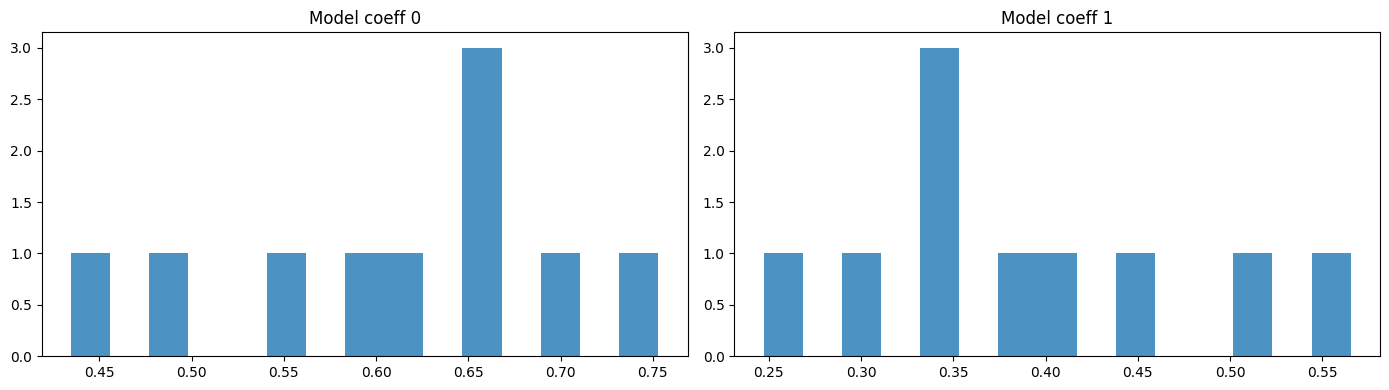

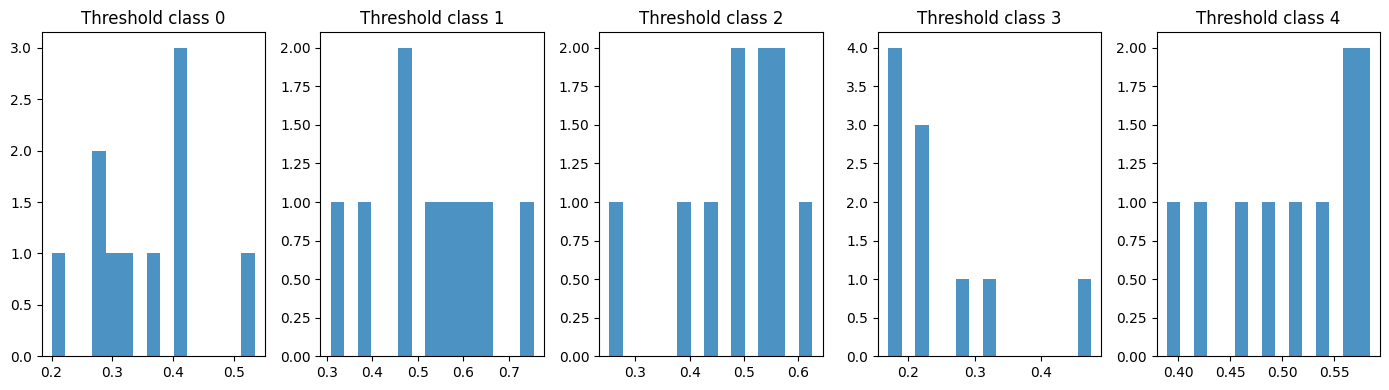

In [108]:
plot_topn_param_histograms(hyperopt_result["top_params"])

In [119]:
hyperopt_result["averaged_params"]

{'coeffs': array([0.60983438, 0.39016562]),
 'thresholds': array([0.34860319, 0.53046765, 0.49064191, 0.24627802, 0.51140278])}

In [110]:
hyperopt_ensemble_probs = (
    torch.sigmoid(torch.cat(nfnetl0_all_preds[2])) * hyperopt_result["averaged_params"]["coeffs"][0] + 
    torch.sigmoid(torch.cat(efnetv2b3_all_preds[2])) * hyperopt_result["averaged_params"]["coeffs"][1]
) 

hyperopt_ensemble_probs_test = (
    torch.sigmoid(torch.stack(nfnetl0_all_preds[0], axis=0)).mean(0) * hyperopt_result["averaged_params"]["coeffs"][0] + 
    torch.sigmoid(torch.stack(efnetv2b3_all_preds[0], axis=0)).mean(0) * hyperopt_result["averaged_params"]["coeffs"][1]
)

In [117]:
evaluate_multilabel_metrics(
    y_true=torch.cat(nfnetl0_all_preds[1]).long().numpy(),
    y_pred=apply_thresholds(hyperopt_ensemble_probs.numpy(), hyperopt_result["averaged_params"]["thresholds"]),
    y_prob=hyperopt_ensemble_probs.numpy(),
    class_names=full_df.columns[1:-2]
)

{'roc_auc': {'per_class': {'Cat': 0.9987117504999096,
   'Dog': 0.9981602285737863,
   'Moris': 0.9973310858266611,
   'Motya': 0.9978544536164441,
   'Biatrix': 0.9975068815259722},
  'macro': 0.9979128800085547},
 'f1': {'per_class': {'Cat': 0.9810765761349152,
   'Dog': 0.9748452784987023,
   'Moris': 0.9122807017543859,
   'Motya': 0.8536585365853658,
   'Biatrix': 0.95},
  'macro': 0.9343722185946739},
 'precision': {'per_class': {'Cat': 0.9767668879344006,
   'Dog': 0.9779691568195473,
   'Moris': 0.896551724137931,
   'Motya': 0.875,
   'Biatrix': 0.9743589743589743},
  'macro': 0.9401293486501707},
 'recall': {'per_class': {'Cat': 0.9854244632657081,
   'Dog': 0.9717412935323383,
   'Moris': 0.9285714285714286,
   'Motya': 0.8333333333333334,
   'Biatrix': 0.926829268292683},
  'macro': 0.9291799573990984},
 'conf_matrices': {'Cat': array([[7064,  119],
         [  74, 5003]]),
  'Dog': array([[7125,  110],
         [ 142, 4883]]),
  'Moris': array([[12198,     6],
         [  

In [118]:
hyperopt_ensemble_sub = create_submission(apply_thresholds(hyperopt_ensemble_probs_test.numpy(), hyperopt_result["averaged_params"]["thresholds"]))
hyperopt_ensemble_sub.to_csv("nfnetl0_efnetv2b3_hyperopt_sub.csv", index=False)

Private: 0.93921

Public: 0.92237

## Stacking

### Incorrect / Leaky Version

We have three folds:

- $X_1$  
- $X_2$  
- $X_3$

For each fold, we train a model on the other folds and generate **out-of-fold predictions**:

$$
\hat{y}_1 = f(X_1 \mid X_2, X_3)
$$

$$
\hat{y}_2 = f(X_2 \mid X_1, X_3)
$$

$$
\hat{y}_3 = f(X_3 \mid X_1, X_2)
$$

We combine them into a stacked feature matrix:

$$
\begin{bmatrix}
X_1 & \hat{y}_1 \\
X_2 & \hat{y}_2 \\
X_3 & \hat{y}_3
\end{bmatrix}
$$

Then a second-level model is trained:

$$
y_i = g\left( X_i,\ \hat{y}_i \right)
$$

Let's consider second-level model trained on $X_2$, $X_3$:

$$
y_1 = g\Big(
    X_1,\, \tilde{y}_1 = f(X_1 \mid X_2, X_3) \mid \;
    X_2,\, \tilde{y}_2 = f(X_2 \mid X_1, X_3),\;
    X_3,\, \tilde{y}_3 = f(X_3 \mid X_1, X_2)
\Big)
$$

This effectively makes:

$$
y_1 = g\Big(
    \mathbf{X_1},\, \tilde{y}_1 = f(X_1 \mid X_2, X_3) \mid \;
    X_2, \mathbf{X_1}, X_3
\Big)
$$

Which means that model is predicting $X_1$, while at the same time conditioned on $X_1$

**LEAKAGE!!!**


## Correct Stacking With Nested (Outer × Inner) Folds

To avoid leakage when generating stacking features, each outer fold must be split into **inner folds** (e.g., 3 subfolds each):

- $X_{1,1}, X_{1,2}, X_{1,3}$
- $X_{2,1}, X_{2,2}, X_{2,3}$
- $X_{3,1}, X_{3,2}, X_{3,3}$

This creates a **3 × 3 nested CV structure**.

---

### Step 1 — Build Out-of-Fold Predictions for Each Outer Fold

For a given outer fold $X_1$, train the model **only** on the other two outer folds $X_2, X_3$.  
But to produce predictions for all samples inside $X_1$, we must avoid in-fold leakage:

#### Inner CV inside each outer fold:

For outer fold $X_1$:

1. Split $X_1$ into 3 inner folds:  
   $X_{1,1}, X_{1,2}, X_{1,3}$

2. For each inner fold $X_{1,i}$:

   Train on:
   $$
   X_1 \setminus X_{1,i}
   $$

   Predict on:
   $$
   X_{1,i}
   $$

   This gives:
   $$
   \hat{y}_{1,i} = f(X_{1,i} \mid X_{1,j\neq i})
   $$

3. Combine:
   $$
   \hat{y}_1 = \hat{y}_{1,1} \cup \hat{y}_{1,2} \cup \hat{y}_{1,3}
   $$

Repeat the same procedure for outer folds $X_2$ and $X_3$.

This yields **fully out-of-fold predictions** for all samples without leakage.

---

### Step 2 — Build the Stacking Matrix

After nested CV, you obtain:

$$
\begin{bmatrix}
X_1 & \hat{y}_1 \\
X_2 & \hat{y}_2 \\
X_3 & \hat{y}_3
\end{bmatrix}
$$

Where each $\hat{y}_i$ was created **without ever training on its own samples**.

Now you can safely train the second-level model:

$$
y_i = g(X_i,\ \hat{y}_i)
$$

---

## Why This Is Correct

Each $\hat{y}_i = \hat{y}_{i,1} \cup \hat{y}_{i,2} \cup \hat{y}_{i,3}$ conditioned purely on data of respective $X_i$, so there will be no leakage on outer folds



In [133]:
full_df_stacking = full_df.drop(columns=["fold"])
full_df_stacking = create_folds(full_df_stacking, n_splits=9)
full_df_stacking["outer_fold"] = full_df_stacking["fold"].map(
    {inner_f + outer_f * 3: outer_f for outer_f in range(3) for inner_f in range(3)}
)
full_df_stacking.head()

,image_id,Cat,Dog,Moris,Motya,Biatrix,balance_column,fold,outer_fold
0,7e17a6e589f9c891857b32bbb3652d19b7d5a215,0,0,0,0,0,No Animals,3,1
1,7ad97bd6c7ef98373f43f2bbd1e41b2bbff4687e,1,0,0,0,0,Cat,3,1
2,d29be872d012d8766c5942847d1d721788fd9511,0,1,0,0,0,Dog,6,2
3,bec7727bfc721629997d782ec020ee555990128f,0,1,0,0,0,Dog,3,1
4,58bb7362153d945f48721004bc8fb2ee73a855b0,0,1,0,0,0,Dog,2,0


In [135]:
def train_and_predict_all_for_one_model_nested(
    input_df, 
    test_df,
    exp_name,
    lightning_training_kwargs,
    nn_model_class, nn_model_config, 
    test_dataset_class, test_dataset_config,
    val_dataset_class, val_dataset_config, val_dataloader_config,
    trained_chkp_paths=None
):
    """
    Trains a first-level model using nested CV:
    - outer_fold splits control the main CV division
    - fold splits create inner folds inside each outer fold
    
    Returns:
    - test_predictions: list of arrays (one per trained model)
    - oof_labels:       list of y_true (in fold order)
    - oof_predictions:  list of y_pred (same ordering)
    """

    test_predictions = []
    oof_labels = []
    oof_predictions = []

    # Loop over OUTER folds
    for outer_f in sorted(np.unique(input_df["outer_fold"])):

        df_outer = input_df[input_df["outer_fold"] == outer_f]
        inner_folds = sorted(np.unique(df_outer["fold"]))

        test_predictions_inner = []

        # Loop over INNER folds
        for inner_f in inner_folds:
            train_df = input_df[
                ((input_df["outer_fold"] == outer_f) & (input_df["fold"] != inner_f))
            ]

            val_df = df_outer[df_outer["fold"] == inner_f]

            # Determine checkpoint path
            if trained_chkp_paths is None:
                trained_model_path = lightning_training(
                    train_df=train_df,
                    val_df=val_df,
                    exp_name=f"logdirs/{exp_name}/outer_{outer_f}_inner_{inner_f}",
                    fold_id=f"{outer_f}_{inner_f}",
                    nn_model_class=nn_model_class,
                    nn_model_config=nn_model_config,
                    val_dataloader_config=val_dataloader_config,
                    val_dataset_class=val_dataset_class,
                    val_dataset_config=val_dataset_config,
                    **lightning_training_kwargs
                )
            else:
                trained_model_path = trained_chkp_paths[(outer_f, inner_f)]

            print(f"Loading model {trained_model_path}")

            # Create inference model
            inf_model = create_inference_model(
                nn_model_class=nn_model_class,
                nn_model_config=nn_model_config,
                checkpoint_path=trained_model_path
            )

            # --- TEST PREDICTIONS ---
            test_preds, _ = run_inference_on_df(
                input_df=test_df,
                nn_model=inf_model,
                dataset_class=test_dataset_class,
                dataset_config=test_dataset_config,
                dataloader_config=val_dataloader_config,
            )
            test_predictions_inner.append(test_preds)

            # --- OOF PREDICTIONS ---
            val_preds, val_ls = run_inference_on_df(
                input_df=val_df,
                nn_model=inf_model,
                dataset_class=val_dataset_class,
                dataset_config=val_dataset_config,
                dataloader_config=val_dataloader_config,
            )
            oof_predictions.append(val_preds)
            oof_labels.append(val_ls)
            
        test_predictions.append(test_predictions_inner)

    return test_predictions, oof_labels, oof_predictions


In [136]:
efnetv2b3_all_preds_stacking = train_and_predict_all_for_one_model_nested(
    input_df=full_df_stacking,
    test_df=pd.read_csv("../../data/cats-and-dogs-plus-plus/sample_submission.csv"),
    exp_name="efnetv2b3_full_stacking",
    lightning_training_kwargs=dict(
        forward_batch_key="targets",
        train_dataset_class=MultilabelImageDataset,
        train_dataset_config=dict(
            img_dir="../../data/cats-and-dogs-plus-plus/train",
            transform=A.Compose([
                A.Resize(224, 224),
                A.VerticalFlip(p=0.5),
                A.HorizontalFlip(p=0.5),
                A.RandomRotate90(p=0.3),
                A.ShiftScaleRotate(
                  shift_limit=0.1,
                  scale_limit=0.15,
                  rotate_limit=15,
                  p=0.5
                ),
                A.RandomBrightnessContrast(
                  brightness_limit=0.2,
                  contrast_limit=0.2,
                  p=0.5
                ),
                A.HueSaturationValue(
                  hue_shift_limit=10,
                  sat_shift_limit=20,
                  val_shift_limit=15,
                  p=0.3
                ),
                A.GaussNoise(var_limit=(10.0, 30.0), p=0.2),
                A.Blur(blur_limit=3, p=0.2),
                A.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
                ToTensorV2()
              ]),
            balance_column="balance_column"
        ),
        use_sampler=True,
        train_dataloader_config={
            "batch_size": 64,
            "shuffle": False,
            "drop_last": True,
            "num_workers": 8,
            "pin_memory": True,
        },
        optimizer_init=lambda model: torch.optim.Adam(model.parameters(), lr=1e-3),
        scheduler_init=lambda optimizer, len_train: torch.optim.lr_scheduler.CosineAnnealingLR(
            optimizer, 
            eta_min=1e-6,
            T_max=len_train * 5,
        ),
        scheduler_params={"interval": "step"},
        forward=lambda: BCEForward(
            torch.nn.BCEWithLogitsLoss(),
            input_key="targets",
            output_key="logits",
        ),
        n_epochs=10,
        main_metric="valid_MultilabelF1Score",
        metric_mode="max",
        metric_input_key="targets",
        metric_output_key="predictions",
        val_metrics=torchmetrics.MetricCollection(
            metrics=[
                torchmetrics.Accuracy(average="macro", task="multilabel", num_classes=len(CLASSES), num_labels=len(CLASSES),),
                torchmetrics.Recall(average="macro", task="multilabel", num_classes=len(CLASSES), num_labels=len(CLASSES),),
                torchmetrics.Precision(average="macro", task="multilabel", num_classes=len(CLASSES), num_labels=len(CLASSES),),
                torchmetrics.F1Score(average="macro", task="multilabel", num_classes=len(CLASSES), num_labels=len(CLASSES),),
            ],
            compute_groups=False
        ),
        train_metrics=torchmetrics.MetricCollection(
            metrics=[
                torchmetrics.Accuracy(average="macro", task="multilabel", num_classes=len(CLASSES), num_labels=len(CLASSES),),
                torchmetrics.Recall(average="macro", task="multilabel", num_classes=len(CLASSES), num_labels=len(CLASSES),),
                torchmetrics.Precision(average="macro", task="multilabel", num_classes=len(CLASSES), num_labels=len(CLASSES),),
                torchmetrics.F1Score(average="macro", task="multilabel", num_classes=len(CLASSES), num_labels=len(CLASSES),),
            ],
            compute_groups=False
        ),
        checkpoint_callback_params=dict(
            save_last=True,
            auto_insert_metric_name=True,
            save_weights_only=True,
            save_on_train_epoch_end=True,
            filename="{epoch}-{step}-{valid_MultilabelF1Score:.3f}",
        ),
        precision_mode="16-mixed",
        wandb_logger_params={
            "project": "kse_deep_learning_course",
        }
    ),
    nn_model_class=timm.create_model, 
    nn_model_config={
        "model_name": "tf_efficientnetv2_b3.in1k",
        "num_classes": len(CLASSES),
        "pretrained": True
    },
    test_dataset_class=MultilabelImageDataset, 
    test_dataset_config=dict(
        img_dir="../../data/cats-and-dogs-plus-plus/test",
        transform=A.Compose([
            A.Resize(224, 224),
            A.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
            ToTensorV2()
        ])
    ),
    val_dataset_class=MultilabelImageDataset, 
    val_dataset_config=dict(
        img_dir="../../data/cats-and-dogs-plus-plus/train",
        transform=A.Compose([
            A.Resize(224, 224),
            A.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
            ToTensorV2()
        ])
    ),
    val_dataloader_config={
        "batch_size": 64,
        "shuffle": False,
        "drop_last": False,
        "num_workers": 8,
        "pin_memory": True,
    },
)

/mnt/disks/ai-training/kse_deep_learning/.venv/lib/python3.10/site-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)
/tmp/ipykernel_199290/1323801523.py:32: UserWarning: Argument(s) 'var_limit' are not valid for transform GaussNoise
  A.GaussNoise(var_limit=(10.0, 30.0), p=0.2),


Training Device : cuda
Using next class weights:
{'Biatrix': 0.125,
 'Cat': 0.0009017132551848512,
 'Dog': 0.0009025270758122744,
 'Moris': 0.1111111111111111,
 'Motya': 0.1,
 'No Animals': 0.0020833333333333333}
Sampler Created


Using 16bit Automatic Mixed Precision (AMP)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


train Loader Len = 42
valid Loader Len = 22


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
/mnt/disks/ai-training/kse_deep_learning/.venv/lib/python3.10/site-packages/lightning/pytorch/utilities/model_summary/model_summary.py:231: Precision 16-mixed is not supported by the model summary.  Estimated model size in MB will not be accurate. Using 32 bits instead.

  | Name           | Type             | Params | Mode 
------------------------------------------------------------
0 | model          | EfficientNet     | 12.8 M | train
1 | _forward       | BCEForward       | 0      | train
2 | _val_metrics   | MetricCollection | 0      | train
3 | _train_metrics | MetricCollection | 0      | train
------------------------------------------------------------
12.8 M    Trainable params
0         Non-trainable params
12.8 M    Total params
51.316    Total estimated model params size (MB)
598       Modules in train mode
0         Modules in eval mode


...

Validation: |                                                                                                 …

`Trainer.fit` stopped: `max_epochs=10` reached.


epoch,▁▁▁▁▂▂▂▂▃▃▃▃▃▃▃▃▃▄▄▄▅▅▅▅▆▆▆▆▆▆▆▇▇▇▇▇▇███
lr-Adam,███▇▆▅▅▄▃▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▂▂▂▂▃▄▅▆▆▆▇▇▇██
train_MultilabelAccuracy,▁▆▇█████▇▇
train_MultilabelF1Score,▁▆▇█████▇▇
train_MultilabelPrecision,▁▇▇█████▇▇
train_MultilabelRecall,▁▅▆█████▇▇
train_avg_loss,█▃▂▁▁▁▁▁▂▂
train_avg_model_time,▂▇▇█▂▁▂▁▁▂
train_loss,█▄▃▄▃▂▂▂▁▂▁▁▁▁▁▁▁▁▁▁▂▁▁▁▁▁▁▁▁▂▁▁▁▁▁▁▁▂▂▂
train_model_time,▂▃▂▂▁▃█▆▆▃▁▄▆█▅▂▅▃▂▁▆▂▁▃▃▃▁▁▁▂▁▅▂▂▂▂▁▁▁▂
+9,...


Loading model /mnt/disks/ai-training/kse_deep_learning/Module_4/Lecture_4/logdirs/efnetv2b3_full_stacking/outer_2_inner_8/checkpoints/epoch=4-step=210-valid_MultilabelF1Score=0.794.ckpt


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 22/22 [00:03<00:00,  6.84it/s]


In [141]:
evaluate_multilabel_metrics(
    y_true=torch.cat(efnetv2b3_all_preds_stacking[1]).long().numpy(),
    y_pred=(torch.sigmoid(torch.cat(efnetv2b3_all_preds_stacking[2])) > 0.5).long().numpy(),
    y_prob=torch.sigmoid(torch.cat(efnetv2b3_all_preds_stacking[2])).numpy(),
    class_names=full_df.columns[1:-2]
)

{'roc_auc': {'per_class': {'Cat': 0.996741521238389,
   'Dog': 0.9934520624245737,
   'Moris': 0.990124724914548,
   'Motya': 0.9631535049770441,
   'Biatrix': 0.9600621982158932},
  'macro': 0.9807068023540897},
 'f1': {'per_class': {'Cat': 0.9700078926598263,
   'Dog': 0.9490562208240308,
   'Moris': 0.7,
   'Motya': 0.5671641791044776,
   'Biatrix': 0.6031746031746031},
  'macro': 0.7578805791525876},
 'precision': {'per_class': {'Cat': 0.9717335441786914,
   'Dog': 0.9683164216193829,
   'Moris': 0.7954545454545454,
   'Motya': 0.76,
   'Biatrix': 0.8636363636363636},
  'macro': 0.8718281749777965},
 'recall': {'per_class': {'Cat': 0.9682883592672838,
   'Dog': 0.930547263681592,
   'Moris': 0.625,
   'Motya': 0.4523809523809524,
   'Biatrix': 0.4634146341463415},
  'macro': 0.6879262418952339},
 'conf_matrices': {'Cat': array([[7040,  143],
         [ 161, 4916]]),
  'Dog': array([[7082,  153],
         [ 349, 4676]]),
  'Moris': array([[12195,     9],
         [   21,    35]]),
 

In [142]:
nfnetl0_all_preds_stacking = train_and_predict_all_for_one_model_nested(
    input_df=full_df_stacking,
    test_df=pd.read_csv("../../data/cats-and-dogs-plus-plus/sample_submission.csv"),
    exp_name="nfnetl0_full_stacking",
    lightning_training_kwargs=dict(
        forward_batch_key="targets",
        train_dataset_class=MultilabelImageDataset,
        train_dataset_config=dict(
            img_dir="../../data/cats-and-dogs-plus-plus/train",
            transform=A.Compose([
                A.Resize(224, 224),
                A.VerticalFlip(p=0.5),
                A.HorizontalFlip(p=0.5),
                A.RandomRotate90(p=0.3),
                A.ShiftScaleRotate(
                  shift_limit=0.1,
                  scale_limit=0.15,
                  rotate_limit=15,
                  p=0.5
                ),
                A.RandomBrightnessContrast(
                  brightness_limit=0.2,
                  contrast_limit=0.2,
                  p=0.5
                ),
                A.HueSaturationValue(
                  hue_shift_limit=10,
                  sat_shift_limit=20,
                  val_shift_limit=15,
                  p=0.3
                ),
                A.GaussNoise(var_limit=(10.0, 30.0), p=0.2),
                A.Blur(blur_limit=3, p=0.2),
                A.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
                ToTensorV2()
              ]),
            balance_column="balance_column"
        ),
        use_sampler=True,
        train_dataloader_config={
            "batch_size": 64,
            "shuffle": False,
            "drop_last": True,
            "num_workers": 8,
            "pin_memory": True,
        },
        optimizer_init=lambda model: torch.optim.Adam(model.parameters(), lr=1e-3),
        scheduler_init=lambda optimizer, len_train: torch.optim.lr_scheduler.CosineAnnealingLR(
            optimizer, 
            eta_min=1e-6,
            T_max=len_train * 5,
        ),
        scheduler_params={"interval": "step"},
        forward=lambda: BCEForward(
            torch.nn.BCEWithLogitsLoss(),
            input_key="targets",
            output_key="logits",
        ),
        n_epochs=10,
        main_metric="valid_MultilabelF1Score",
        metric_mode="max",
        metric_input_key="targets",
        metric_output_key="predictions",
        val_metrics=torchmetrics.MetricCollection(
            metrics=[
                torchmetrics.Accuracy(average="macro", task="multilabel", num_classes=len(CLASSES), num_labels=len(CLASSES),),
                torchmetrics.Recall(average="macro", task="multilabel", num_classes=len(CLASSES), num_labels=len(CLASSES),),
                torchmetrics.Precision(average="macro", task="multilabel", num_classes=len(CLASSES), num_labels=len(CLASSES),),
                torchmetrics.F1Score(average="macro", task="multilabel", num_classes=len(CLASSES), num_labels=len(CLASSES),),
            ],
            compute_groups=False
        ),
        train_metrics=torchmetrics.MetricCollection(
            metrics=[
                torchmetrics.Accuracy(average="macro", task="multilabel", num_classes=len(CLASSES), num_labels=len(CLASSES),),
                torchmetrics.Recall(average="macro", task="multilabel", num_classes=len(CLASSES), num_labels=len(CLASSES),),
                torchmetrics.Precision(average="macro", task="multilabel", num_classes=len(CLASSES), num_labels=len(CLASSES),),
                torchmetrics.F1Score(average="macro", task="multilabel", num_classes=len(CLASSES), num_labels=len(CLASSES),),
            ],
            compute_groups=False
        ),
        checkpoint_callback_params=dict(
            save_last=True,
            auto_insert_metric_name=True,
            save_weights_only=True,
            save_on_train_epoch_end=True,
            filename="{epoch}-{step}-{valid_MultilabelF1Score:.3f}",
        ),
        precision_mode="16-mixed",
        wandb_logger_params={
            "project": "kse_deep_learning_course",
        }
    ),
    nn_model_class=timm.create_model, 
    nn_model_config={
        "model_name": "nfnet_l0.ra2_in1k",
        "num_classes": len(CLASSES),
        "pretrained": True
    },
    test_dataset_class=MultilabelImageDataset, 
    test_dataset_config=dict(
        img_dir="../../data/cats-and-dogs-plus-plus/test",
        transform=A.Compose([
            A.Resize(224, 224),
            A.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
            ToTensorV2()
        ])
    ),
    val_dataset_class=MultilabelImageDataset, 
    val_dataset_config=dict(
        img_dir="../../data/cats-and-dogs-plus-plus/train",
        transform=A.Compose([
            A.Resize(224, 224),
            A.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
            ToTensorV2()
        ])
    ),
    val_dataloader_config={
        "batch_size": 64,
        "shuffle": False,
        "drop_last": False,
        "num_workers": 8,
        "pin_memory": True,
    },
)

/mnt/disks/ai-training/kse_deep_learning/.venv/lib/python3.10/site-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)
/tmp/ipykernel_199290/1119549678.py:32: UserWarning: Argument(s) 'var_limit' are not valid for transform GaussNoise
  A.GaussNoise(var_limit=(10.0, 30.0), p=0.2),


Training Device : cuda
Using next class weights:
{'Biatrix': 0.125,
 'Cat': 0.0009017132551848512,
 'Dog': 0.0009025270758122744,
 'Moris': 0.1111111111111111,
 'Motya': 0.1,
 'No Animals': 0.0020833333333333333}
Sampler Created


Using 16bit Automatic Mixed Precision (AMP)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


train Loader Len = 42
valid Loader Len = 22


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
/mnt/disks/ai-training/kse_deep_learning/.venv/lib/python3.10/site-packages/lightning/pytorch/utilities/model_summary/model_summary.py:231: Precision 16-mixed is not supported by the model summary.  Estimated model size in MB will not be accurate. Using 32 bits instead.

  | Name           | Type             | Params | Mode 
------------------------------------------------------------
0 | model          | NormFreeNet      | 32.8 M | train
1 | _forward       | BCEForward       | 0      | train
2 | _val_metrics   | MetricCollection | 0      | train
3 | _train_metrics | MetricCollection | 0      | train
------------------------------------------------------------
32.8 M    Trainable params
0         Non-trainable params
32.8 M    Total params
131.124   Total estimated model params size (MB)
239       Modules in train mode
0         Modules in eval mode


...

Validation: |                                                                                                 …

`Trainer.fit` stopped: `max_epochs=10` reached.


epoch,▁▁▁▁▂▂▂▂▂▂▃▃▃▃▃▃▃▃▄▄▅▅▅▅▆▆▆▆▆▆▇▇▇███████
lr-Adam,██▇▇▇▆▅▄▃▃▂▂▂▁▁▁▁▁▁▁▁▁▂▂▂▄▄▅▆▆▆▇▇▇▇▇████
train_MultilabelAccuracy,▁▆▇████▇▆▅
train_MultilabelF1Score,▁▆▇█████▆▆
train_MultilabelPrecision,▁▆▇█████▆▆
train_MultilabelRecall,▁▆▇█████▆▅
train_avg_loss,█▄▂▁▁▁▁▂▃▄
train_avg_model_time,▄█▁▇▃▇▇▇▄▃
train_loss,█▇▆▄▆▃▃▂▃▂▃▂▁▃▂▁▁▁▁▁▁▂▁▁▂▂▁▁▁▂▁▂▆▃▂▃▃▂▃▃
train_model_time,▂▂▃▂▁▄▄▆▂▁▂▃▂▃▁▂▆▂▂▂▁▂▂▂▁▂▂▂▁█▂▁▁▃▂▂▁▂▂▂
+9,...


Loading model /mnt/disks/ai-training/kse_deep_learning/Module_4/Lecture_4/logdirs/nfnetl0_full_stacking/outer_2_inner_8/checkpoints/epoch=7-step=336-valid_MultilabelF1Score=0.758.ckpt


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 22/22 [00:04<00:00,  5.00it/s]


In [143]:
evaluate_multilabel_metrics(
    y_true=torch.cat(nfnetl0_all_preds_stacking[1]).long().numpy(),
    y_pred=(torch.sigmoid(torch.cat(nfnetl0_all_preds_stacking[2])) > 0.5).long().numpy(),
    y_prob=torch.sigmoid(torch.cat(nfnetl0_all_preds_stacking[2])).numpy(),
    class_names=full_df.columns[1:-2]
)

{'roc_auc': {'per_class': {'Cat': 0.9927175924837963,
   'Dog': 0.9883092347522925,
   'Moris': 0.9634136348738119,
   'Motya': 0.942025426965679,
   'Biatrix': 0.9560440657193215},
  'macro': 0.9685019909589803},
 'f1': {'per_class': {'Cat': 0.9521149241819633,
   'Dog': 0.9369802624987477,
   'Moris': 0.7254901960784313,
   'Motya': 0.5714285714285714,
   'Biatrix': 0.5833333333333334},
  'macro': 0.7538694575042094},
 'precision': {'per_class': {'Cat': 0.9646250252678391,
   'Dog': 0.943502824858757,
   'Moris': 0.8043478260869565,
   'Motya': 0.7142857142857143,
   'Biatrix': 0.6774193548387096},
  'macro': 0.8208361490675953},
 'recall': {'per_class': {'Cat': 0.9399251526492023,
   'Dog': 0.930547263681592,
   'Moris': 0.6607142857142857,
   'Motya': 0.47619047619047616,
   'Biatrix': 0.5121951219512195},
  'macro': 0.7039144600373551},
 'conf_matrices': {'Cat': array([[7008,  175],
         [ 305, 4772]]),
  'Dog': array([[6955,  280],
         [ 349, 4676]]),
  'Moris': array([[

In [157]:
stacking_test = torch.concatenate(
    (
        torch.stack([torch.sigmoid(torch.stack(el, axis=0)).mean(0) for el in nfnetl0_all_preds_stacking[0]], axis=0).mean(0), 
        torch.stack([torch.sigmoid(torch.stack(el, axis=0)).mean(0) for el in efnetv2b3_all_preds_stacking[0]], axis=0).mean(0)
    ),
    axis=-1
)

(torch.Size([12260, 10]), torch.Size([18390, 10]))

In [185]:
stacking_val_preds, stacking_val_labels, stacking_test_preds = [], [], []

for out_f_idx in sorted(np.unique(full_df_stacking["outer_fold"])):
    inner_start = out_f_idx * 3
    inner_end   = (out_f_idx + 1) * 3
    
    inner_for_this_outer = np.arange(inner_start, inner_end)    
    inner_not_this_outer = np.setdiff1d(all_inner_folds, inner_for_this_outer)

    print(inner_for_this_outer, inner_not_this_outer)

    local_val_x = torch.concatenate(
        (
            torch.sigmoid(torch.cat([nfnetl0_all_preds_stacking[2][idx] for idx in inner_for_this_outer])), 
            torch.sigmoid(torch.cat([efnetv2b3_all_preds_stacking[2][idx] for idx in inner_for_this_outer]))
        ),
        axis=-1
    ).numpy()

    local_val_y = torch.cat([nfnetl0_all_preds_stacking[1][idx] for idx in inner_for_this_outer]).long().numpy()

    local_train_x = torch.concatenate(
        (
            torch.sigmoid(torch.cat([nfnetl0_all_preds_stacking[2][idx] for idx in inner_not_this_outer])), 
            torch.sigmoid(torch.cat([efnetv2b3_all_preds_stacking[2][idx] for idx in inner_not_this_outer]))
        ),
        axis=-1
    ).numpy()

    local_train_y = torch.cat([nfnetl0_all_preds_stacking[1][idx] for idx in inner_not_this_outer]).long().numpy()
    
    second_level_model = OneVsRestClassifier(
        LogisticRegression(max_iter=100)
    )
    second_level_model.fit(local_train_x, local_train_y)

    stacking_val_preds.append(second_level_model.predict_proba(local_val_x))
    stacking_val_labels.append(local_val_y)
    stacking_test_preds.append(second_level_model.predict_proba(stacking_test))

[0 1 2] [3 4 5 6 7 8]
[3 4 5] [0 1 2 6 7 8]
[6 7 8] [0 1 2 3 4 5]


In [191]:
evaluate_multilabel_metrics(
    y_true=np.concatenate(stacking_val_labels).astype(bool),
    y_pred=np.concatenate(stacking_val_preds) > 0.5,
    y_prob=np.concatenate(stacking_val_preds),
    class_names=full_df.columns[1:-2]
)

{'roc_auc': {'per_class': {'Cat': 0.9959592894511532,
   'Dog': 0.9933848655822478,
   'Moris': 0.9829534812941892,
   'Motya': 0.9543569596769793,
   'Biatrix': 0.8935184907950233},
  'macro': 0.9640346173599186},
 'f1': {'per_class': {'Cat': 0.9745260663507109,
   'Dog': 0.9636072785442912,
   'Moris': 0.6666666666666666,
   'Motya': 0.5084745762711864,
   'Biatrix': 0.5357142857142857},
  'macro': 0.7297977747094281},
 'precision': {'per_class': {'Cat': 0.977034250643437,
   'Dog': 0.9682539682539683,
   'Moris': 0.9354838709677419,
   'Motya': 0.8823529411764706,
   'Biatrix': 1.0},
  'macro': 0.9526250062083236},
 'recall': {'per_class': {'Cat': 0.9720307268071696,
   'Dog': 0.9590049751243781,
   'Moris': 0.5178571428571429,
   'Motya': 0.35714285714285715,
   'Biatrix': 0.36585365853658536},
  'macro': 0.6343778720936266},
 'conf_matrices': {'Cat': array([[7067,  116],
         [ 142, 4935]]),
  'Dog': array([[7077,  158],
         [ 206, 4819]]),
  'Moris': array([[12202,     2

In [193]:
hyperopt_ensemble_sub = create_submission(np.stack(stacking_test_preds,axis=0).mean(0) > 0.5)
hyperopt_ensemble_sub.to_csv("stacking.csv", index=False)

/tmp/ipykernel_199290/1145384442.py:105: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[False  True False ... False  True  True]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  sample_sub.iloc[:,1:] = test_hard_preds
/tmp/ipykernel_199290/1145384442.py:105: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[ True False False ...  True False False]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  sample_sub.iloc[:,1:] = test_hard_preds
/tmp/ipykernel_199290/1145384442.py:105: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[False False False ... False False False]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  sample_sub.iloc[:,1:] = test_hard_preds
/tmp/ip

Private: 0.64035

Public: 0.56767

## To Sum Up


| Model / Method                         | Validation F1 | Public LB | Private LB |
|----------------------------------------|---------------|-----------|------------|
| **EfficientNetV2-B3**                  | 0.89052       | 0.91472   | 0.88738    |
| **NFNet-L0**                           | 0.92781       | 0.92771   | 0.93393    |
| **NFNet-L0 (Last + Best checkpoints)** | 0.92694       | 0.93036   | 0.93870    |
| **Simple Average Ensemble**            | 0.93479       | 0.93003   | 0.92309    |
| **Hyperopt-Optimized Avg. Ensemble**   | 0.93437       | 0.92237   | 0.93921    |
| **Stacking (LogReg Second-Level Model)**       | 0.72980       | 0.56767   | 0.64035    |

